# 🎯 UD03 - Proyecto Integrador: Análisis de Airbnb Valencia

**Autor:** Igor Ostyak

**Dataset:** Airbnb Valencia

**Nivel:** Intermedio

**Fecha:** Diciembre 2025


---


## 1. Introducción y Objetivos
En este proyecto analizaremos el mercado de alquiler vacacional en Valencia utilizando datos públicos de Inside Airbnb.

**Objetivo Principal:**
Analizar la estrategia de precios por zona, los tipos de alojamiento y la ocupación

**Datasets Utilizados:**
1.  `listings.csv.gz`: Información detallada de los alojamientos
2.  `calendar.csv.gz`: Disponibilidad y precios futuros

### 1.1 Importación de librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Carga del Dataset
Cargamos el archivo  `listings.csv.gz`

In [2]:
df = pd.read_csv('../datos/listings.csv.gz')

print(f"Dataset cargado con exito.")
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")



Dataset cargado con exito.
Dimensiones del dataset: 7844 filas x 79 columnas


### 1.3 Exploración de la Estructura y Tipos de Datos
Visualizamos las primeras filas y revisamos los tipos de datos asignados por Pandas para detectar inconsistencias.

In [3]:
print("="*70)
print("INFO DATASET")
print("="*70)

display(df.info())

print("="*70)
print("PRIMERAS FILAS")
print("="*70)

display(df.head(10))

print("="*70)
print("ESTADISTICAS BASICAS")
print("="*70)

display(df.describe())

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7844 entries, 0 to 7843
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            7844 non-null   int64  
 1   listing_url                                   7844 non-null   object 
 2   scrape_id                                     7844 non-null   int64  
 3   last_scraped                                  7844 non-null   object 
 4   source                                        7844 non-null   object 
 5   name                                          7844 non-null   object 
 6   description                                   7668 non-null   object 
 7   neighborhood_overview                         3277 non-null   object 
 8   picture_url                                   7844 non-null   object 
 9   host_id                                       7844

None

PRIMERAS FILAS


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,48154,https://www.airbnb.com/rooms/48154,20250923203019,2025-09-24,city scrape,Precioso apartamento con wifi,Second floor on a farm from the late 19th cent...,Very close neighborhood to the city's old town...,https://a0.muscache.com/pictures/1109085/9c0d4...,219476,...,4.80,4.52,4.52,VT-41540-V,f,4,4,0,0,1.08
1,137143,https://www.airbnb.com/rooms/137143,20250923203019,2025-09-24,city scrape,PENTHOUSE ON FRONT LINE BEACH,NaN,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,670775,...,5.00,4.00,4.00,VT32745V,f,5,5,0,0,0.01
2,149715,https://www.airbnb.com/rooms/149715,20250923203019,2025-09-24,city scrape,1900 Style Valencian Beach Home for 10px,Typical town house with 5 bedrooms and 4 bathr...,"Surrounded by historic houses, authentic res...",https://a0.muscache.com/pictures/808b4883-c57f...,5947,...,4.89,4.63,4.62,ESFCTU000046025000580569000000000000000000VT-3...,f,1,1,0,0,1.81
3,165971,https://www.airbnb.com/rooms/165971,20250923203019,2025-09-24,city scrape,★ Architectural touch! ★,"Hola! I am ready to welcome you in my apt., wh...",Just outside the old city centre (one block aw...,https://a0.muscache.com/pictures/10878830/ade6...,791187,...,4.88,4.84,4.84,VT-32757-V,t,8,8,0,0,3.34
4,182221,https://www.airbnb.com/rooms/182221,20250923203019,2025-09-24,city scrape,Apartments Calatrava City Valencia,NaN,NaN,https://a0.muscache.com/pictures/1161513/9f7ac...,1315567,...,4.67,4.33,4.44,VT-38755-V,f,1,1,0,0,0.07
5,193326,https://www.airbnb.com/rooms/193326,20250923203019,2025-09-24,city scrape,Habitación balcón cerca de playa y universidades,"Sunny room with balcony, desk and WiFi for wor...",NaN,https://a0.muscache.com/pictures/42849831-e837...,937597,...,4.95,4.78,4.79,ESHFNT0000460250003821180020000000000000000000...,f,2,0,2,0,2.31
6,225070,https://www.airbnb.com/rooms/225070,20250923203019,2025-09-24,city scrape,Habitación cerca de la playa y universidades,A bright room with a desk and WiFi to work. <b...,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,937597,...,4.95,4.77,4.80,ESHFNT0000460250003821180020000000000000000000...,f,2,0,2,0,1.65
7,252608,https://www.airbnb.com/rooms/252608,20250923203019,2025-09-24,city scrape,Apartamento privilegiado en el corazón de Vale...,NaN,IT IS THE SAFEST AND MOST SELECT AREA OF THE H...,https://a0.muscache.com/pictures/3453638/6dfbb...,1326001,...,4.50,4.75,4.75,NaN,f,1,1,0,0,0.02
8,253764,https://www.airbnb.com/rooms/253764,20250923203019,2025-09-24,previous scrape,Sea view apartment with terrace at Cabanyal beach,"Completely renovated flat, on the third floor ...",Right next to the house we found a good tapas ...,https://a0.muscache.com/pictures/2455142/5fe5c...,1332880,...,4.81,4.77,4.30,CV-VUT0033846-V,f,2,2,0,0,0.46
9,260929,https://www.airbnb.com/rooms/260929,20250923203019,2025-09-23,city scrape,Queen size bed & private bathroom by Miguel Inn,Bedroom with very confortable queen size bed a...,Our neighborhood is right on the edge of the c...,https://a0.muscache.com/pictures/hosting/Hosti...,140702,...,4.87,4.85,4.70,NaN,f,3,0,3,0,1.14


ESTADISTICAS BASICAS


,id,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,7.844000e+03,7.844000e+03,7.844000e+03,7838.000000,7838.000000,7844.000000,7844.000000,7844.000000,6976.000000,7532.000000,...,6867.000000,6866.000000,6866.000000,6866.000000,6866.000000,7844.000000,7844.000000,7844.000000,7844.000000,6867.000000
mean,8.243448e+17,2.025092e+13,2.890802e+08,24.134856,32.786170,39.467440,-0.364102,3.505609,1.249857,1.537440,...,4.668585,4.783029,4.776902,4.674837,4.558345,12.325089,11.090388,1.221698,0.002677,1.695209
std,5.535320e+17,0.000000e+00,2.288511e+08,80.419663,117.960142,0.018601,0.022572,1.880761,0.574487,0.988074,...,0.446722,0.365012,0.411926,0.391328,0.477696,20.770843,20.964792,2.993117,0.073996,1.665714
min,4.815400e+04,2.025092e+13,5.947000e+03,1.000000,1.000000,39.279986,-0.425840,1.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,5.086848e+07,2.025092e+13,7.425452e+07,1.000000,2.000000,39.461480,-0.379972,2.000000,1.000000,1.000000,...,4.560000,4.750000,4.750000,4.560000,4.450000,1.000000,1.000000,0.000000,0.000000,0.470000
50%,1.020877e+18,2.025092e+13,2.292401e+08,4.000000,5.000000,39.468510,-0.371105,4.000000,1.000000,1.000000,...,4.790000,4.880000,4.900000,4.760000,4.670000,3.000000,2.000000,0.000000,0.000000,1.170000
75%,1.295046e+18,2.025092e+13,5.042718e+08,15.000000,19.000000,39.474893,-0.344124,4.000000,1.500000,2.000000,...,4.930000,4.980000,5.000000,4.920000,4.820000,11.000000,9.000000,1.000000,0.000000,2.490000
max,1.514336e+18,2.025092e+13,7.196722e+08,1354.000000,2768.000000,39.545790,-0.276280,16.000000,11.500000,17.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,103.000000,103.000000,22.000000,3.000000,37.710000


### 1.4 Inspección Visual de Variables Problematicas
Seleccionamos una muestra de columnas que tienen problemas de formato (precios con simbolos, fechas como texto, booleanos como letras) para confirmar el formato que tienen para posteriormente realizar la limpieza

In [4]:
# Verificacion visual de patrones a corregir
cols_muestra = [
    'price',              
    'host_response_rate', 
    'last_review',        
    'id',                 
    'host_is_superhost'   
]

print("="*70)
print("MUESTRA DE COLUMNAS")
print("="*70)

display(df[cols_muestra].head())

print("="*70)
print("Valores unicos en bathrooms_text")
print("="*70)
display(df['bathrooms_text'].value_counts())


MUESTRA DE COLUMNAS


,price,host_response_rate,last_review,id,host_is_superhost
0,$83.00,100%,2025-09-15,48154,f
1,$390.00,100%,2013-07-02,137143,f
2,$245.00,100%,2025-09-15,149715,f
3,$124.00,100%,2025-09-03,165971,t
4,$137.00,100%,2025-03-17,182221,f


Valores unicos en bathrooms_text


bathrooms_text
1 bath               4378
2 baths              1197
1 shared bath         799
1 private bath        476
1.5 baths             331
2 shared baths        173
1.5 shared baths      116
3 baths                77
Shared half-bath       58
2.5 baths              52
0 baths                32
Half-bath              30
4 baths                19
0 shared baths         18
3.5 baths              16
Private half-bath      14
4 shared baths         11
2.5 shared baths        9
5 baths                 8
3 shared baths          6
5 shared baths          4
4.5 baths               3
10 shared baths         2
10 baths                1
3.5 shared baths        1
7 baths                 1
6 baths                 1
4.5 shared baths        1
11.5 baths              1
Name: count, dtype: int64

### 1.5 Identificación de Problemas de Calidad

Analizamos los problemas que puede tener el dataset como:
* Valores nulos
* Duplicados
* Valores imposibles
* Inconsistencias

Primero revisamos que columnas tenemos

In [5]:
print("=" * 70)
print("LISTA DE COLUMNAS")
print("=" * 70)

df.columns.tolist()

LISTA DE COLUMNAS


['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

#### 1.5.1 Valores nulos

NULOS POR COLUMNA


,Total Filas Vacias,Porcentaje
calendar_updated,7844,100.00
host_neighbourhood,6100,77.77
neighborhood_overview,4567,58.22
neighbourhood,4567,58.22
host_about,3627,46.24
license,3311,42.21
host_location,2157,27.50
review_scores_value,978,12.47
review_scores_location,978,12.47
review_scores_communication,978,12.47


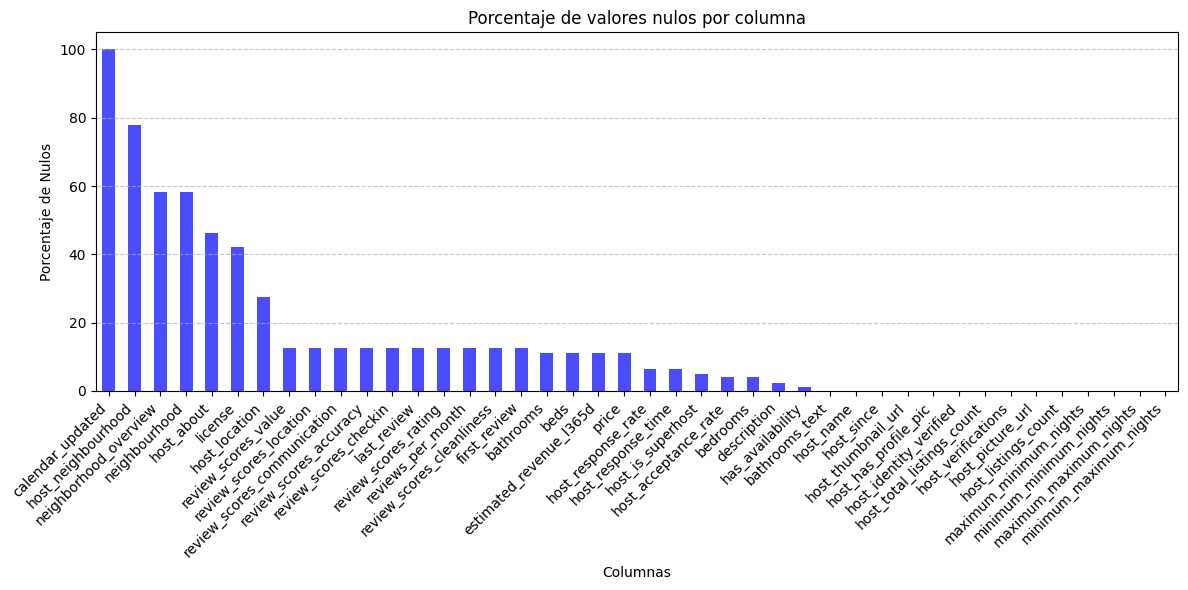

In [6]:

total_nulos = df.isnull().sum()
nulos_porcentaje = df.isnull().mean() * 100

tabla_nulos = pd.DataFrame({
    "Total Filas Vacias":total_nulos,
    "Porcentaje":nulos_porcentaje.round(2)
})

print("=" * 70)
print("NULOS POR COLUMNA")
print("=" * 70)

display(tabla_nulos[tabla_nulos['Total Filas Vacias'] > 0].sort_values(by='Porcentaje', ascending=False))

nulos_porcentaje_filtrado = nulos_porcentaje[nulos_porcentaje > 0]

nulos_porcentaje_sorted = nulos_porcentaje_filtrado.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
nulos_porcentaje_sorted.plot(kind='bar', color='blue', alpha=0.7)

plt.title('Porcentaje de valores nulos por columna')
plt.xlabel('Columnas')
plt.ylabel('Porcentaje de Nulos')
plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()  
plt.show()


#### 1.5.2 Duplicados

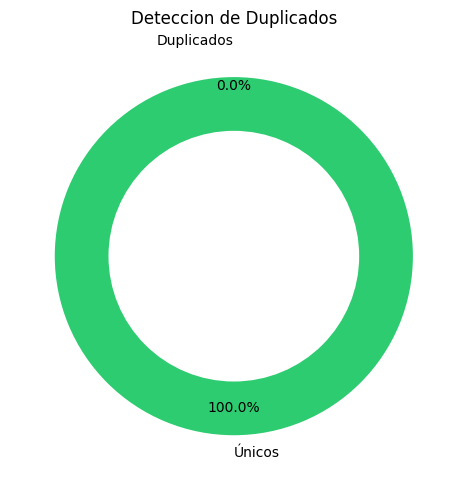

No hay filas repetidas en el dataset.


In [7]:
# 1. Preparamos los datos
num_duplicados = df.duplicated().sum()
num_unicos = len(df) - num_duplicados
datos = [num_unicos, num_duplicados]
etiquetas = ['Únicos', 'Duplicados']
colores = ['#2ecc71', '#e74c3c']

# 2. Configuración del Grafico
plt.figure(figsize=(7, 5))

# Creamos el pie chart
plt.pie(datos, labels=etiquetas, colors=colores, autopct='%1.1f%%', 
        startangle=90, pctdistance=0.85, explode=(0, 0.1))

circulo_centro = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(circulo_centro)

plt.title(f'Deteccion de Duplicados', fontsize=12)
plt.tight_layout()
plt.show()

if num_duplicados == 0:
    print("No hay filas repetidas en el dataset.")
else:
    print(f"Se encontraron {num_duplicados} filas duplicadas")
    display(df[df.duplicated()])

#### 1.5.3 Valores imposibles

In [8]:
cols_logica = [
    'minimum_nights', 'maximum_nights', 'availability_365', 'accommodates', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating'
]

print("=" * 70)
print("Minimos y Maximos")
print("=" * 70)

display(df[cols_logica].describe().T[['count', 'min', 'max']])

Minimos y Maximos


,count,min,max
minimum_nights,7844.0,1.0,366.0
maximum_nights,7844.0,1.0,1125.0
availability_365,7844.0,0.0,365.0
accommodates,7844.0,1.0,16.0
bedrooms,7532.0,0.0,17.0
beds,6976.0,0.0,23.0
number_of_reviews,7844.0,0.0,935.0
review_scores_rating,6867.0,0.0,5.0


#### 1.5.4 Inconsistencias

In [9]:
print("=" * 70)
print("TIPOS DE HABITACION")
print("=" * 70)

display(df['room_type'].value_counts().sort_index())


print("=" * 70)
print("TIPOS DE PROPIEDAD")
print("=" * 70)

display(df['property_type'].value_counts().sort_index())

print("=" * 70)
print("BARRIOS")
print("=" * 70)

display(df['neighbourhood_cleansed'].value_counts().sort_index())

TIPOS DE HABITACION


room_type
Entire home/apt    5782
Hotel room           16
Private room       2036
Shared room          10
Name: count, dtype: int64

TIPOS DE PROPIEDAD


property_type
Boat                                    13
Camper/RV                                5
Casa particular                          8
Castle                                   1
Earthen home                             1
Entire bungalow                          1
Entire cabin                             2
Entire chalet                            2
Entire condo                           172
Entire cottage                           2
Entire guest suite                       6
Entire guesthouse                        2
Entire home                            191
Entire loft                            451
Entire place                             4
Entire rental unit                    4722
Entire serviced apartment              114
Entire townhouse                        32
Entire vacation home                    24
Entire villa                             1
Private room                             1
Private room in bed and breakfast       72
Private room in cabin                   

BARRIOS


neighbourhood_cleansed
AIORA            349
ALBORS           100
ARRANCAPINS      209
BENICALAP        128
BENIFERRI         12
                ... 
TORMOS            56
TORREFIEL         70
TRES FORQUES      27
TRINITAT          46
VARA DE QUART     10
Name: count, Length: 85, dtype: int64

### 1.6 Conclusiones y Plan de Limpieza

Despues de revisar los datos paso a paso , aque dejo apuntado todo lo que tengo que arreglar en la siguiente fase:

**1. Columnas que sobran:**
* Voy a eliminar todas las columnas que no aportan ningun valor al analisis, como las URLs, los IDs de scraping y las descripciones largas de texto.
* También me cargo la columna `calendar_updated` porque vimos en la gráfica de nulos que está 100% vacía.

**2. Duplicados:**
* He comprobado que no existen filas duplicadas en el dataset

**3. Tipos de datos incorrectos:**
* **El Precio:** He visto que la columna `price` es de tipo object (texto) porque tiene el símbolo `$` y comas. Tengo que limpiarla y pasarla a numero para poder calcular medias.
* **Las Fechas:** Columnas como `last_review` o `host_since` estan como texto, asi que habra que convertirlas a formato fecha para poder trabajar con ellas.

**4. Gestión de Nulos (Visto en el 1.5.1):**
* **Criterio de Calidad:** He decidido eliminar las columnas que tengan mas del 50% de nulos. Considero que intentar rellenar tanta información inventada introduciria demasiado ruido en el analisis.
* La columna `bathrooms`se va a eliminar ya que tiene bastantes mas nulos que la columna `bathrooms_text`, de la cual sacaremos el numero de baños a partir del texto (teniendo en cuenta que "Half-bath" cuenta como 0.5) y se creara una nueva columna `shared_bath` para diferenciar de si es compartido o no, ya que esto afecta al precio.
* **Nulos pequeños:** Para el resto de columnas importantes con pocos nulos (como `bedrooms`), intentaré rellenarlos con la media/mediana o eliminare esas pocas filas.

**5. Valores raros y Logica:**
* **Noches minimas:** He visto alojamientos que piden un mínimo de 366 noches. Como quiero analizar turismo y no alquiler de larga estancia, tendre que filtrar esos casos.
* **Camas a cero:** Hay pisos que ponen que tienen 0 camas pero caben varias personas. Toca revisar eso para ver si se puede arreglar usando el numero de habitaciones.

## 2. LIMPIEZA Y TRANSFORMACIÓN DE DATOS
En esta fase ejecutamos el plan definido: 
* Eliminación de columnas 
* Corrección de tipos de datos
* Extracción de datos utiles
* Imputación de valores faltantes.

### 2.1 LIMPIEZA DE DATOS

#### 2.1.1 CREACION DE COPIA DE TRABAJO Y ELIMINACIÓN DE COLUMNAS

In [10]:
# COPIA DE SEGURIDAD
df_original = df.copy()

# Limpiamos los nulos que tienen mas del 50% de nulos
umbral = 0.5
cols_nulls = df.columns[df.isnull().mean() > umbral]

print(f"Columnas eliminadas por exceso de nulos (> {umbral*100}%):")
print(list(cols_nulls))

df.drop(columns=cols_nulls, inplace=True)

#Limpiamos manualmente las columnas irrelevantes
cols_to_drop = [
    # IDENTIFICADORES Y URLS--------------------------------------------
    'listing_url', 
    'scrape_id', 
    'last_scraped', 
    'source', 
    'picture_url',
    'host_url', 
    'host_thumbnail_url', 
    'host_picture_url', 
    'calendar_last_scraped',
    'host_name',
    'host_verifications',
    'host_has_profile_pic',
    # TEXTOS LARGOS-------------------------------------------------------
    'description',
    'neighborhood_overview',
    'host_about',
    'host_location',
    'host_neighbourhood', 
    'neighbourhood',
    # REDUNDANCIAS DE NOCHES----------------------------------------------
    'minimum_minimum_nights', 
    'maximum_minimum_nights', 
    'minimum_maximum_nights', 
    'maximum_maximum_nights',
    'minimum_nights_avg_ntm', 
    'maximum_nights_avg_ntm',
    # REDUNDANCIAS DE DISPONIBILIDAD--------------------------------------
    'has_availability',
    'availability_30',
    'availability_60',
    'availability_90',
    'availability_eoy',
    # REDUNDANCIAS DE REVIEWS---------------------------------------------
    'number_of_reviews_ltm',
    'number_of_reviews_l30d',
    'number_of_reviews_ly',
    # DATOS ESTIMADOS-----------------------------------------------------
    'estimated_occupancy_l365d',
    'estimated_revenue_l365d',
    # OTROS---------------------------------------------------------------
    'bathrooms',
    'license',
    'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms',
]

# Borramos ignorando errores (por si alguna ya la borró el paso anterior)
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f"\nDimensiones finales tras limpieza: {df.shape}")

Columnas eliminadas por exceso de nulos (> 50.0%):
['neighborhood_overview', 'host_neighbourhood', 'neighbourhood', 'calendar_updated']

Dimensiones finales tras limpieza: (7844, 39)


#### 2.1.2 CORRECCIÓN DE TIPOS

PRECIO

In [11]:
# Quitamos '$' y ',' y convertimos a float
df['price'] = df['price'].str.replace('$', '', regex=False)
df['price'] = df['price'].str.replace(',', '', regex=False).astype(float)

FECHAS

In [12]:
cols_fechas = ['last_review', 'first_review', 'host_since']
for col in cols_fechas:
    df[col] = pd.to_datetime(df[col], errors='coerce')

PORCENTAJES

In [13]:
cols_percent = ['host_response_rate', 'host_acceptance_rate']

for col in cols_percent:
    # Quitamos el '%' y convertimos a float
    df[col] = df[col].str.replace('%', '', regex=False).astype(float)

#### 2.1.3 EXTRACCION Y LIMPIEZA: BAÑOS

In [14]:
# Si dice "shared" es True, si no, es False (Privado)
df['shared_bath'] = df['bathrooms_text'].str.contains('shared', case=False, na=False)

# 2. LIMPIEZA DEL NÚMERO
# Estandarizamos "Half-bath" a "0.5"
df['bathrooms_clean'] = df['bathrooms_text'].str.replace('Half-bath', '0.5', case=False)
df['bathrooms_clean'] = df['bathrooms_clean'].str.replace('Shared half-bath', '0.5', case=False)
df['bathrooms_clean'] = df['bathrooms_clean'].str.replace('Private half-bath', '0.5', case=False)

# Extraemos el valor numérico
df['bathrooms'] = df['bathrooms_clean'].str.extract(r'(\d+\.?\d*)').astype(float)

# Borramos la columna temporal 'bathrooms_clean' y la columna con texto 'bathrooms_text' para no ensuciar
df.drop(columns=['bathrooms_clean', 'bathrooms_text'], inplace=True)

display(df[['bathrooms', 'shared_bath']].head())

,bathrooms,shared_bath
0,1.0,False
1,1.5,False
2,4.0,False
3,1.0,False
4,1.0,False


#### 2.1.4 GESTION DE NULOS

In [15]:
df['bedrooms'] = df['bedrooms'].fillna(1) # Asumimos que tiene 1 habitacion
df['beds'] = df['beds'].replace(0, np.nan) # Si tiene 0 camas lo ponemos a NaN para posteriormente ponerle las camas dependiendo de las habitaciones
df['beds'] = df['beds'].fillna(df['bedrooms']) # Asumimos que si hay 1 habitacion hay 1 cama
df['bathrooms'] = df['bathrooms'].fillna(1) # Asumimos que tiene 1 baño

# Rellenamos textos faltantes con "Desconocido"
cols_texto = ['host_response_time', 'neighbourhood_cleansed', 'property_type']
for col in cols_texto:
    if col in df.columns:
        df[col] = df[col].fillna('Desconocido')

# Si es nulo, asumimos que no lo es (False)
if 'host_is_superhost' in df.columns:
    df['host_is_superhost'] = df['host_is_superhost'].fillna('f')

# Eliminamos estancias de larga duracion
df = df[df['minimum_nights'] <= 180]
# Eliminamos alojamientos sin capacidad, no puede haber un alojamiento para maximo 0 personas
df = df[df['accommodates'] > 0]
# Eliminamos filas sin precio
df = df.dropna(subset=['price'])

#### 2.1.5 REVISION DE DATOS

In [16]:
print(f"Dimensiones del dataset limpio: {df.shape}")

print("Tipos de datos (Dtypes):")
print(df.dtypes)

print("=" * 70)
print("Conteo de Nulos restantes (Solo deberían quedar Reviews/Textos)")
print("=" * 70)

nulos_restantes = df.isnull().sum()
print(nulos_restantes[nulos_restantes > 0])

print("=" * 70)
print("Muestra de datos")
print("=" * 70)
display(df.head())

Dimensiones del dataset limpio: (6967, 40)
Tipos de datos (Dtypes):
id                                         int64
name                                      object
host_id                                    int64
host_since                        datetime64[ns]
host_response_time                        object
host_response_rate                       float64
host_acceptance_rate                     float64
host_is_superhost                         object
host_listings_count                      float64
host_total_listings_count                float64
host_identity_verified                    object
neighbourhood_cleansed                    object
neighbourhood_group_cleansed              object
latitude                                 float64
longitude                                float64
property_type                             object
room_type                                 object
accommodates                               int64
bedrooms                                 float64
b

,id,name,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,reviews_per_month,shared_bath,bathrooms
0,48154,Precioso apartamento con wifi,219476,2010-09-01,within a few hours,100.0,96.0,f,4.0,4.0,...,4.63,4.85,4.80,4.52,4.52,f,4,1.08,False,1.0
1,137143,PENTHOUSE ON FRONT LINE BEACH,670775,2011-06-06,within a few hours,100.0,100.0,f,5.0,5.0,...,5.00,5.00,5.00,4.00,4.00,f,5,0.01,False,1.5
2,149715,1900 Style Valencian Beach Home for 10px,5947,2009-01-03,within an hour,100.0,98.0,f,1.0,1.0,...,4.58,4.85,4.89,4.63,4.62,f,1,1.81,False,4.0
3,165971,★ Architectural touch! ★,791187,2011-07-07,within an hour,100.0,100.0,t,9.0,20.0,...,4.88,4.89,4.88,4.84,4.84,t,8,3.34,False,1.0
4,182221,Apartments Calatrava City Valencia,1315567,2011-10-20,within an hour,100.0,44.0,f,1.0,2.0,...,4.44,4.67,4.67,4.33,4.44,f,1,0.07,False,1.0


### 2.2 ESTADISTICAS DESCRIPTIVAS CON NUMPY

In [17]:
precios = df['price'].values
disponibilidad = df['availability_365'].values
puntuacion = df['review_scores_rating'].dropna().values
noches_min = df['minimum_nights'].values

# Funcion para calcular las estadisticas
def estadisticas_numpy(nombre, array):
    print("=" * 70)
    print(f"ANALISIS DE: {nombre.upper()}")
    print("=" * 70)
    print(f"Total datos:          {len(array)}")
    print(f"Media (Promedio):     {np.mean(array):.2f}")
    print(f"Mediana (Centro):     {np.median(array):.2f}")
    print(f"Desviacion (Std):     {np.std(array):.2f}")
    print("-" * 30)
    print(f"Minimo:               {np.min(array):.2f}")
    print(f"Maximo:               {np.max(array):.2f}")
    print("-" * 30)
    
    # Percentiles
    p25, p50, p75, p90, p95, p99 = np.percentile(array, [25, 50, 75, 90, 95, 99])
    
    print(f"Percentil 25% (Q1):   {p25:.2f}")
    print(f"Percentil 50% (Q2):   {p50:.2f}")
    print(f"Percentil 75% (Q3):   {p75:.2f}")
    print(f"Percentil 90%:        {p90:.2f}")
    print(f"Percentil 95%:        {p95:.2f}")
    print(f"Percentil 99%:        {p99:.2f}")
    print("\n")

estadisticas_numpy("Precio (€)", precios)
estadisticas_numpy("Disponibilidad", disponibilidad)
estadisticas_numpy("Puntuacion Global (0-5)", puntuacion)
estadisticas_numpy("Noches Minimas", noches_min)

ANALISIS DE: PRECIO (€)
Total datos:          6967
Media (Promedio):     164.32
Mediana (Centro):     102.00
Desviacion (Std):     733.20
------------------------------
Minimo:               8.00
Maximo:               40000.00
------------------------------
Percentil 25% (Q1):   71.00
Percentil 50% (Q2):   102.00
Percentil 75% (Q3):   140.00
Percentil 90%:        198.00
Percentil 95%:        264.00
Percentil 99%:        847.76


ANALISIS DE: DISPONIBILIDAD
Total datos:          6967
Media (Promedio):     198.97
Mediana (Centro):     208.00
Desviacion (Std):     112.99
------------------------------
Minimo:               0.00
Maximo:               365.00
------------------------------
Percentil 25% (Q1):   90.00
Percentil 50% (Q2):   208.00
Percentil 75% (Q3):   309.00
Percentil 90%:        342.00
Percentil 95%:        357.00
Percentil 99%:        365.00


ANALISIS DE: PUNTUACION GLOBAL (0-5)
Total datos:          6151
Media (Promedio):     4.67
Mediana (Centro):     4.78
Desviacion (St

#### Interpretación

Sobre la Media y la Mediana Lo que mas destaca es la diferencia en el precio. La media sale 164€, pero la mediana es solo 102€. Esto significa que la media esta inflada porque hay algunos pisos con precios desorbitados (como es el maximo de 40000€) que tiran del promedio hacia arriba. La mediana refleja mejor el precio real de un piso normal.

Claramente el precio es la variable con mas dispersión. Hay desde habitaciones por 8€ hasta lujos extremos de 40000€. Hay mucha diferencia entre unos y otros. En cambio, en las puntuaciones pasa lo contrario: hay muy poca variacion, casi todos los pisos tienen notas muy parecidas.

Los percentiles me han servido para ver dos cosas:

* En Precio: El 99% de los pisos valen menos de 847€. Esto me confirma que los precios de 40.000€ son casos rarisimos o errores que se tendran que filtrar, porque no representan el mercado real.

* En Reviews: Me ha sorprendido que el percentil 25 sea un 4.58. Es decir, que en Airbnb tener un 4.5 es estar en la parte baja. Las notas estan muy concentradas en la parte alta, es decir casi nadie tiene una mala puntuación.

### 2.3 DETECCION DE OUTLIERS

In [18]:
print("=" * 70)
print("INVESTIGACIÓN DE VALORES EXTREMOS")
print("=" * 70)

# PRECIO
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
limite_precio = Q3 + 1.5 * IQR

outliers_precio = df[df['price'] > limite_precio]

print("Lamite matematico calculado (Precio):", limite_precio)
print("Cantidad de pisos por encima del límite:", len(outliers_precio))
print("\nEjemplos de precios altos:")
display(outliers_precio[['name', 'price', 'neighbourhood_cleansed']].sort_values(by='price', ascending=False).head(5))

print("\n")

# NOCHES MINIMAS
outliers_noches = df[df['minimum_nights'] > 30]

print("Cantidad de pisos con mas de 30 noches:", len(outliers_noches))
print("Ejemplos de estancias largas:")
display(outliers_noches[['name', 'minimum_nights']].sort_values(by='minimum_nights', ascending=False).head(5))

INVESTIGACIÓN DE VALORES EXTREMOS
Lamite matematico calculado (Precio): 243.5
Cantidad de pisos por encima del límite: 419

Ejemplos de precios altos:


,name,price,neighbourhood_cleansed
7731,Confortable apartamento cerca de la playa,40000.0,CABANYAL-CANYAMELAR
5027,Vivir en Valencia,10011.0,MESTALLA
3832,La Casita de la Reina,10000.0,CABANYAL-CANYAMELAR
6069,Apartamento Malvarrosa,10000.0,LA MALVA-ROSA
5828,Lujoso ático Palau de la Música,10000.0,PENYA-ROJA




Cantidad de pisos con mas de 30 noches: 154
Ejemplos de estancias largas:


,name,minimum_nights
312,For a student girl-Wifi-Near center,180
1689,Apartamento playa y universidades Valencia,180
7259,Habitación céntrica en Valencia para chica,180
7677,Apartamento residencial Valencia,150
1815,CR4- Room close to the Universities and Beach.,150


#### 2.3.1 VISUALIZACION DE OUTLIERS

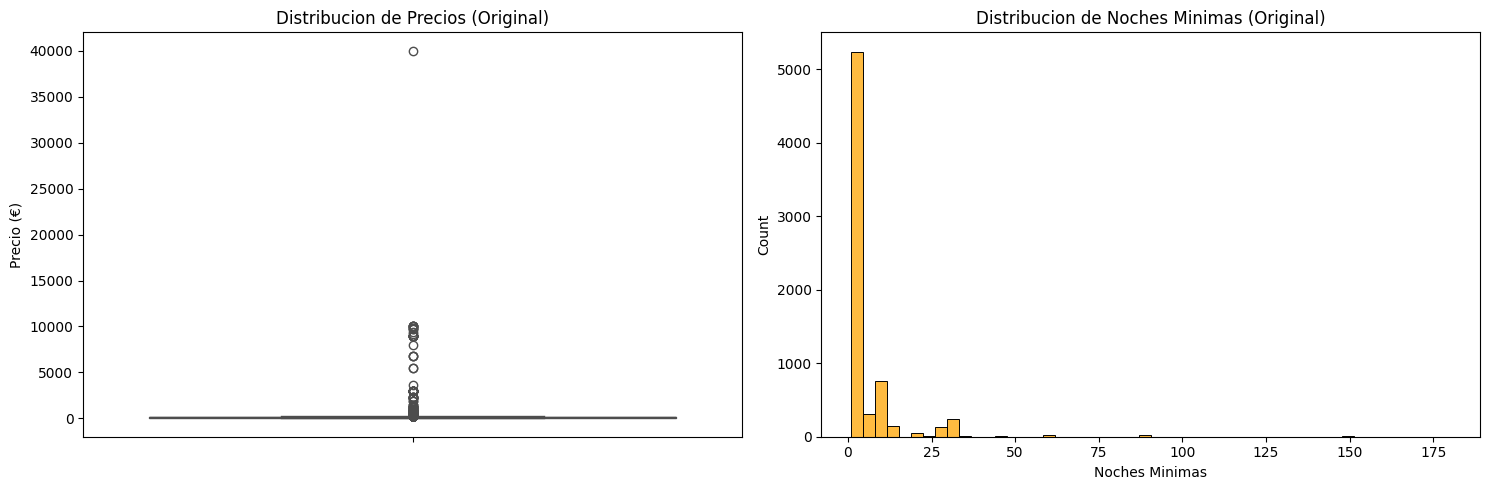

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de Precio
sns.boxplot(y=df['price'], ax=ax[0], color='blue')
ax[0].set_title('Distribucion de Precios (Original)')
ax[0].set_ylabel('Precio (€)')

# Gráfico de Noches
sns.histplot(df['minimum_nights'], ax=ax[1], bins=50, color='orange')
ax[1].set_title('Distribucion de Noches Minimas (Original)')
ax[1].set_xlabel('Noches Minimas')

plt.tight_layout()
plt.show()

#### 2.3.2 LIMPIEZA

Registros eliminados: 569
Total registros finales: 6398


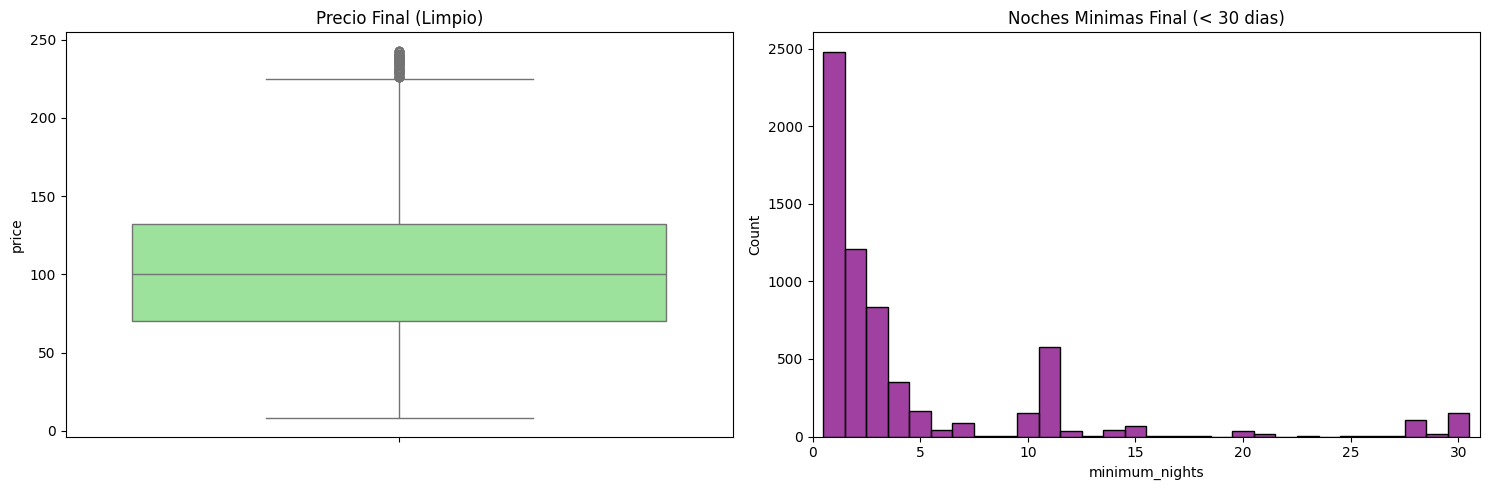

In [20]:
tope_precio = limite_precio
tope_noches = 30

# Nos quedamos con el precio dentro del limite y noches menos de 30
df_sin_outliers = df[(df['price'] <= tope_precio) & (df['minimum_nights'] <= tope_noches)]

print("Registros eliminados:", len(df) - len(df_sin_outliers))
print("Total registros finales:", len(df_sin_outliers))

# Comprobación visual final
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Precio limpio
sns.boxplot(y=df_sin_outliers['price'], ax=ax[0], color='lightgreen')
ax[0].set_title('Precio Final (Limpio)')

# Noches limpias
sns.histplot(df_sin_outliers['minimum_nights'], ax=ax[1], bins=30, discrete=True, color='purple')
ax[1].set_title('Noches Minimas Final (< 30 dias)')
ax[1].set_xlim(0, 31)

plt.tight_layout()
plt.show()

#### 2.3.3 Decisión y Justificación sobre Outliers

He decidido eliminar los outliers tanto en la variable `price` como en `minimum_nights`.


* **En el caso del PRECIO:**
    * **¿Son errores o reales?** Al revisar los datos, encontré valores extremos (como 40000€/noche) que claramente son errores de introducción de datos. Aunque existiera algun alojamiento de lujo real por encima del limite calculado (aprox. 250€), mantener valores tan extremos distorsiona completamente la media y las desviaciones estandar, impidiendo ver la realidad del mercado estandar. Por eso, aplicamos el filtro IQR.

* **En el caso de NOCHES MINIMAS:**
    * **¿Son errores o reales?** Los valores altos (90, 180 dias) son valores legitimos (alquiler residencial seguramente), no son errores. Sin embargo, los elimino porque el objetivo de este estudio es analizar el turismo. Un alquiler que exige 6 meses de estancia minima pertenece a otro mercado y no compite con el alquiler vacacional. Incluirlos sesgaria el analisis de disponibilidad y precios.

### 2.4 ANALISIS DE DISTRIBUCIONES

ANALISIS DE DISTRIBUCIONES Y COMPARATIVAS


C:\Users\igor\AppData\Local\Temp\ipykernel_7072\968802679.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sin_outliers, x='room_type', y='price', palette='Set2', ax=ax[1,0])
C:\Users\igor\AppData\Local\Temp\ipykernel_7072\968802679.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='neighbourhood_cleansed', y='price', palette='viridis', ax=ax[1,1])


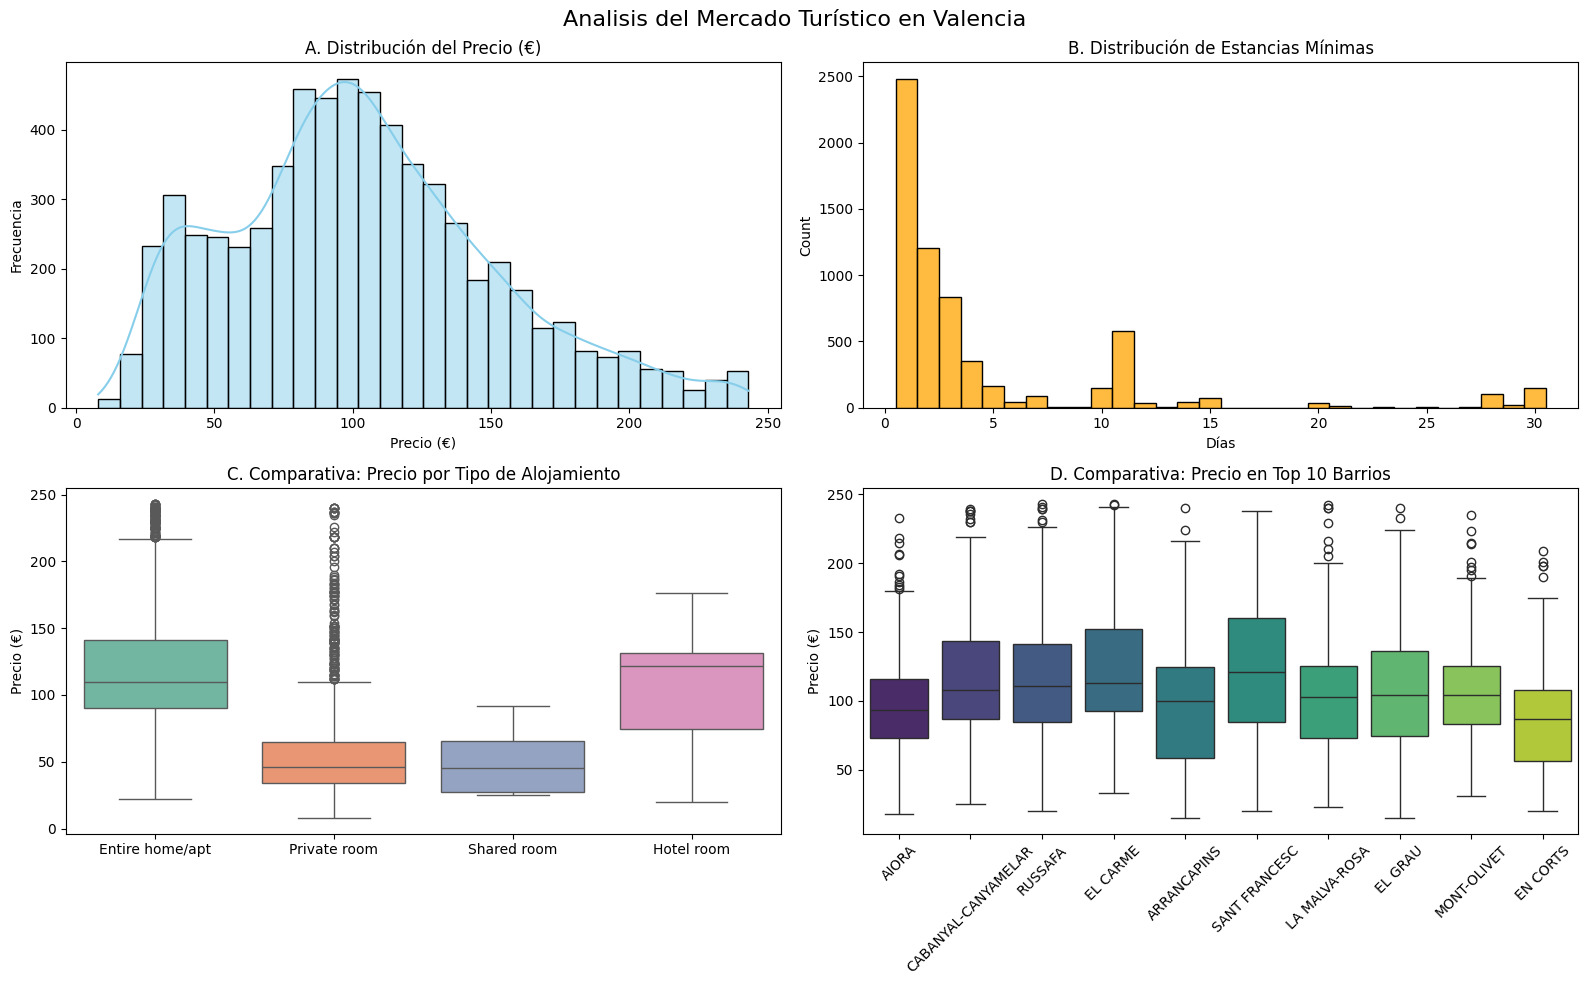

In [21]:
print("=" * 70)
print("ANALISIS DE DISTRIBUCIONES Y COMPARATIVAS")
print("=" * 70)

fig, ax = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Analisis del Mercado Turístico en Valencia', fontsize=16)

# Distribución del Precio
sns.histplot(df_sin_outliers['price'], bins=30, kde=True, color='skyblue', ax=ax[0,0])
ax[0,0].set_title('A. Distribución del Precio (€)')
ax[0,0].set_xlabel('Precio (€)')
ax[0,0].set_ylabel('Frecuencia')

# Distribución de Noches Minimas
sns.histplot(df_sin_outliers['minimum_nights'], discrete=True, color='orange', ax=ax[0,1])
ax[0,1].set_title('B. Distribución de Estancias Mínimas')
ax[0,1].set_xlabel('Días')


# Precio vs Tipo de Alojamiento
sns.boxplot(data=df_sin_outliers, x='room_type', y='price', palette='Set2', ax=ax[1,0])
ax[1,0].set_title('C. Comparativa: Precio por Tipo de Alojamiento')
ax[1,0].set_ylabel('Precio (€)')
ax[1,0].set_xlabel('')

# Precio vs Barrio
top_barrios = df_sin_outliers['neighbourhood_cleansed'].value_counts().head(10).index
df_top = df_sin_outliers[df_sin_outliers['neighbourhood_cleansed'].isin(top_barrios)]

sns.boxplot(data=df_top, x='neighbourhood_cleansed', y='price', palette='viridis', ax=ax[1,1])
ax[1,1].set_title('D. Comparativa: Precio en Top 10 Barrios')
ax[1,1].set_ylabel('Precio (€)')
ax[1,1].set_xlabel('')
ax[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**1. Sobre la forma de las distribuciones (Histogramas)**

En el primer grafico del precio se ve que la distribución no es una campana perfecta. Tiene un sesgo hacia la derecha, aunque es bastante leve gracias a que ya limpiamos los valores extremos en el paso anterior. Esto nos dice que la gran mayoria de la oferta se mueve en precios medios y bajos, y que la cantidad de pisos disminuye suavemente a medida que sube el precio.

En el grafico de las noches minimas se ve claramente un comportamiento con multiples picos a lo largo del grafico. Aunque la inmensa mayoria de alquileres se concentran al principio, observamos repuntes curiosos alrededor de los 10 dias y al final de la escala, llegando a los 30 dias. Esto confirma que hay varios tipos de turismo: el de fin de semana (mayoritario), el de media estancia y el mensual.

**2. Sobre los outliers y las comparativas (Boxplots)**

He usado los boxplots para buscar outliers visualmente. En el grafico C, sobre todo en las habitaciones privadas, se ven muchos puntos por encima de las cajas. Mi conclusión es que estos valores no son errores, sino alojamientos de categoría superior o de lujo que, aunque se salen de lo normal, son datos reales que debemos mantener en el estudio.

Por ultimo, al comparar los grupos se ve clara la diferencia de precios. Los pisos enteros son bastante mas caros y tienen precios mas variados que las habitaciones. Tambien se nota en el grafico de los barrios que la ubicación influye mucho, con zonas centricas teniendo precios base mas altos que los barrios perifericos.

### 2.5 MATRIZ DE CORRELACIÓN

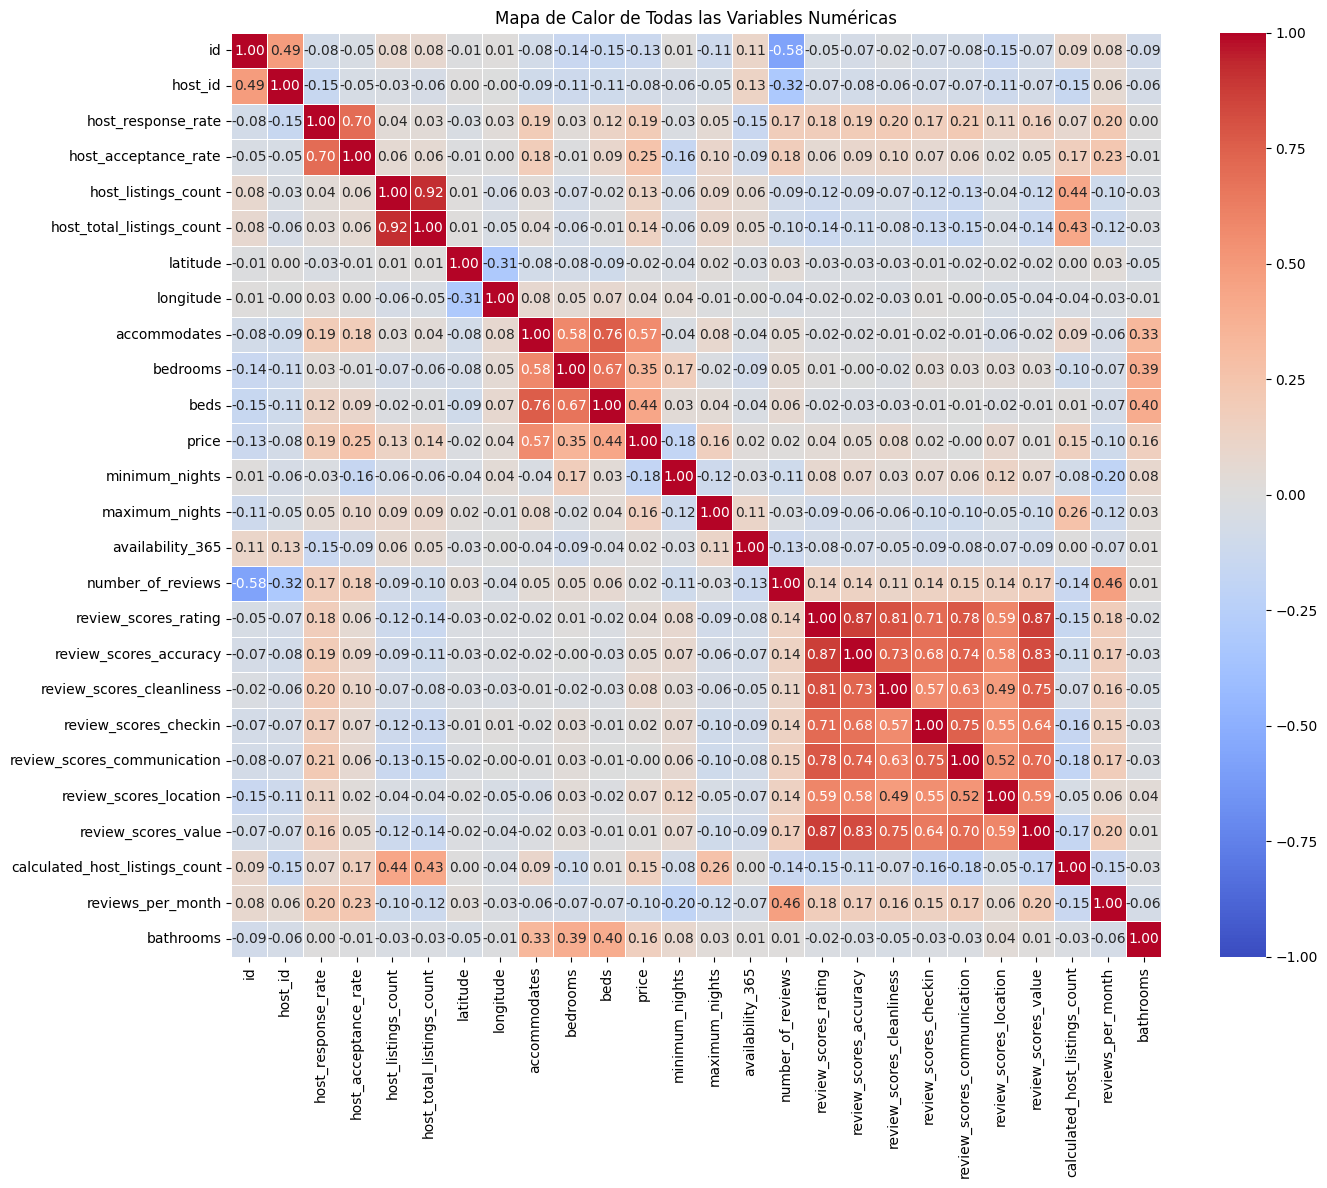

In [22]:
df_numerico = df_sin_outliers.select_dtypes(include=[np.number])

corr_matrix = df_numerico.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5, vmin=-1, vmax=1)

plt.title('Mapa de Calor de Todas las Variables Numéricas')
plt.show()

Para este análisis he calculado la correlación entre todas las variables numericas del dataset. El objetivo era identificar que factores están relacionados entre si y detectar posibles datos redundantes.

**1. Identificación de relaciones fuertes (Correlación > 0.5)**

Al mirar el mapa de calor, he encontrado dos bloques principales donde la correlación supera claramente el 0.5.

El primero es el grupo de las variables de tamaño. He visto que la capacidad del alojamiento tiene una correlación muy alta, de 0.76, con el número de camas y de 0.58 con el número de habitaciones. Esto nos indica que estas variables estan ligadas entre si.

El segundo bloque es el de las puntuaciones de las reseñas. Todas las variables de puntuación tienen correlaciones muy altas entre ellas, casi todas por encima de 0.70. Esto significa que cuando un usuario valora bien un aspecto, tiende a valorar bien el resto.

**2. Sentido en el contexto y relación con el precio**

Estas correlaciones tienen todo el sentido en el contexto del negocio. Es logico que si un piso es mas grande tenga mas camas, y es normal que la satisfacción del cliente sea general y no aislada por categorias.

Respecto a la variable mas importante, el precio, la correlación mas fuerte que he encontrado es con la capacidad de alojamiento, con un valor de 0.57. Esto confirma que el factor principal para determinar el precio es el tamaño del inmueble y cuanta gente cabe en el.

**3. Sorpresas y precauciones**

Lo que me ha parecido mas sorprendente es que no existe relación entre el precio y la cantidad de reseñas. La correlación es prácticamente cero, lo que implica que ser un piso muy popular o tener muchas opiniones no hace que el precio suba automaticamente.

Por ultimo, he tenido cuidado de no interpretar las filas de los IDs o las coordenadas. Aunque en el gráfico aparecen con colores, son correlaciones espurias o falsas porque un identificador numerico no tiene ninguna relación logica de causa y efecto con el precio o las caracteristicas del piso.

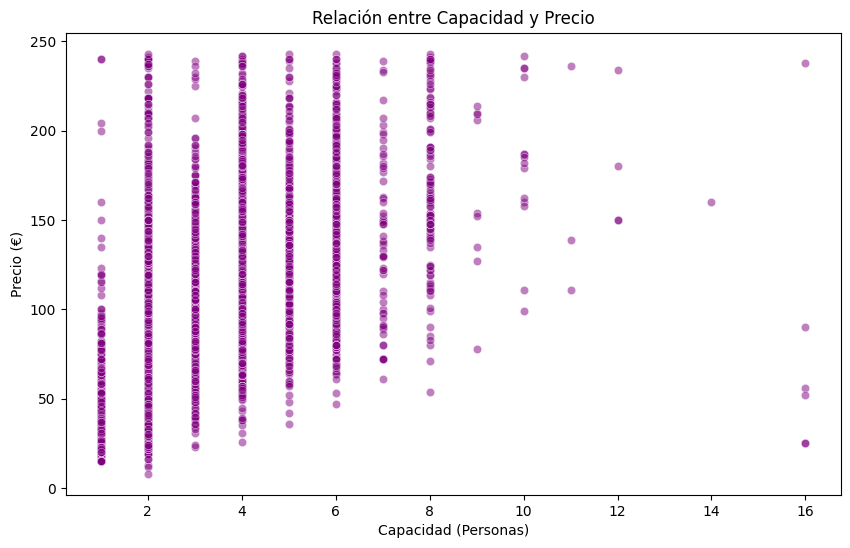

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sin_outliers, x='accommodates', y='price', alpha=0.5, color='purple')
plt.title('Relación entre Capacidad y Precio')
plt.xlabel('Capacidad (Personas)')
plt.ylabel('Precio (€)')
plt.show()

**Análisis visual de la relación Precio-Capacidad**

Para profundizar en la correlación más fuerte que encontré en la matriz anterior (0.57), he generado un gráfico de dispersión.

El gráfico confirma visualmente que existe una tendencia positiva: a medida que nos movemos hacia la derecha (más capacidad), los puntos se sitúan más arriba (mayor precio). Se ve claramente que el "suelo" de precio sube; es decir, es muy difícil encontrar un alojamiento para 6 o 8 personas que sea tan barato como uno para 2.

Sin embargo, también vemos que la relación no es perfecta. Hay alojamientos con capacidad para muchas personas (10 o más) que tienen precios moderados, y alojamientos para 2 personas que tocan el techo de precio. Esto refuerza mi conclusión anterior: el tamaño importa, pero la ubicación y la calidad también definen el precio final.

### 2.6. Interpretación y Síntesis

Para terminar esta fase de analisis exploratorio, resumo los descubrimientos más importantes y las decisiones que he tomado con los datos durante el proceso.

#### Hallazgos estadísticos y distribuciones

Lo primero que he notado es que las variables principales no siguen una distribución normal perfecta. El precio tiene un sesgo hacia la derecha, lo que indica que la gran mayoria de la oferta en Valencia es economica o de precio medio, mientras que la oferta de lujo es mucho mas escasa.

Por otro lado, la variable de noches minimas tiene un comportamiento multimodal muy interesante. Los graficos han mostrado picos claros en estancias de 1 a 3 dias y otro repunte en los 30 dias, lo que confirma que hay dos modelos de negocio: el turistico de fin de semana y el alquiler de temporada.

#### Decisiones sobre los outliers

He aplicado una estrategia mixta dependiendo de si el dato parecia un error o un negocio real.

Para el precio y las noches minimas decidi eliminar los valores extremos. Lo hice asi porque encontrar precios de 40000 euros o estancias obligatorias de medio año distorsionaba el estudio y claramente no eran datos representativos del turismo.

Sin embargo, para otras variables como el numero de reseñas o la capacidad, decidi mantener los outliers. Al visualizarlos entendi que esos valores altos no son errores, sino que corresponden a alojamientos muy populares o con mucha trayectoria en la plataforma. Son datos reales que representan la oferta mas exitosa y por tanto no debemos borrarlos.

#### Correlaciones clave

Gracias a la matriz de correlación y al gráfico de dispersión he sacado dos conclusiones para el futuro. La primera es que el tamaño es el factor que mas influye en el precio. La correlación y la nube de puntos confirman que cuanta mas gente cabe, mas sube el precio base del alojamiento.

La segunda conclusión es la redundancia de datos. He confirmado que el numero de camas, habitaciones y capacidad dicen practicamente lo mismo. De cara a la siguiente fase, podria simplificar el dataset eliminando alguna de estas columnas repetidas sin perder información valiosa.

## 3 Manipulación Avanzada con Pandas

### 3.1. AGRUPACIONES (GROUPBY)

Top 5 Barrios mas caros


,Precio Medio (€),Total Alojamientos,Rating Promedio
neighbourhood_cleansed,,,
FAITANAR,178.000000,1,NaN
MAHUELLA-TAULADELLA,150.000000,1,4.860000
PENYA-ROJA,142.729730,74,4.758824
CIUTAT DE LES ARTS I DE LES CIENCIES,129.378049,82,4.667468
EL PLA DEL REMEI,127.756757,37,4.664000


C:\Users\igor\AppData\Local\Temp\ipykernel_7072\1706308588.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=barrio_stats.head(10).index, y=barrio_stats.head(10)['Precio Medio (€)'], palette='viridis')


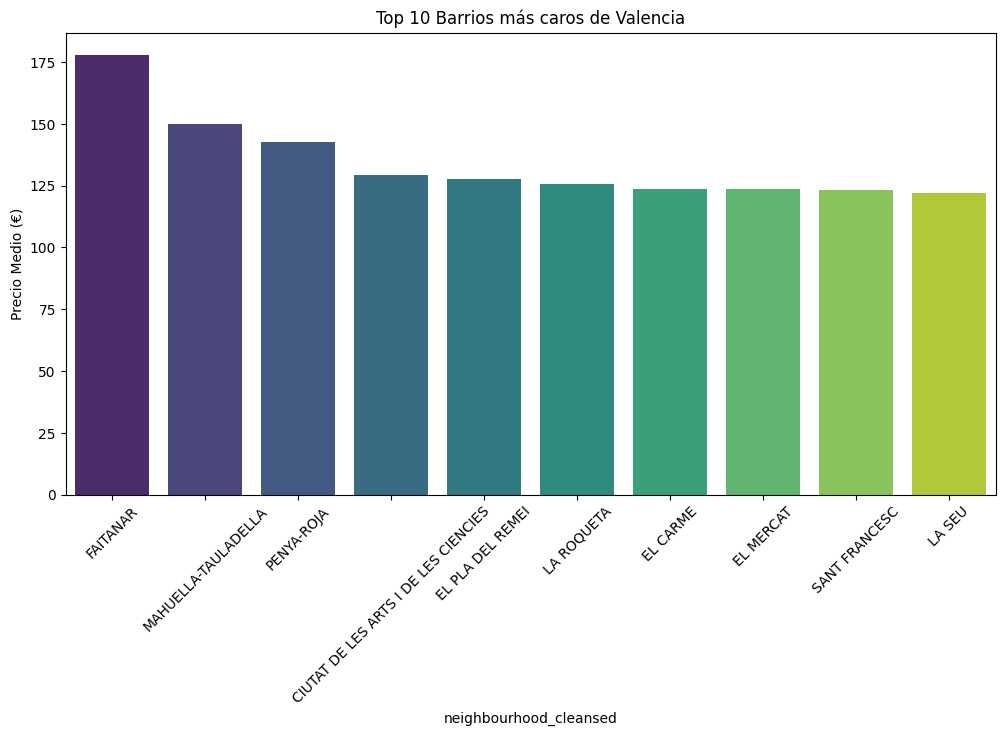

In [24]:
# Calculamos: Precio medio, Cantidad de pisos y Puntuación media
barrio_stats = df_sin_outliers.groupby('neighbourhood_cleansed').agg({
    'price': 'mean',
    'id': 'count',
    'review_scores_rating': 'mean'
}).sort_values(by='price', ascending=False)

barrio_stats.columns = ['Precio Medio (€)', 'Total Alojamientos', 'Rating Promedio']
print("=" * 70)
print("Top 5 Barrios mas caros")
print("=" * 70)

display(barrio_stats.head(5))

plt.figure(figsize=(12, 6))
sns.barplot(x=barrio_stats.head(10).index, y=barrio_stats.head(10)['Precio Medio (€)'], palette='viridis')
plt.title('Top 10 Barrios más caros de Valencia')
plt.xticks(rotation=45)
plt.ylabel('Precio Medio (€)')
plt.show()

### 3.2. PIVOT TABLES Y CROSSTABS

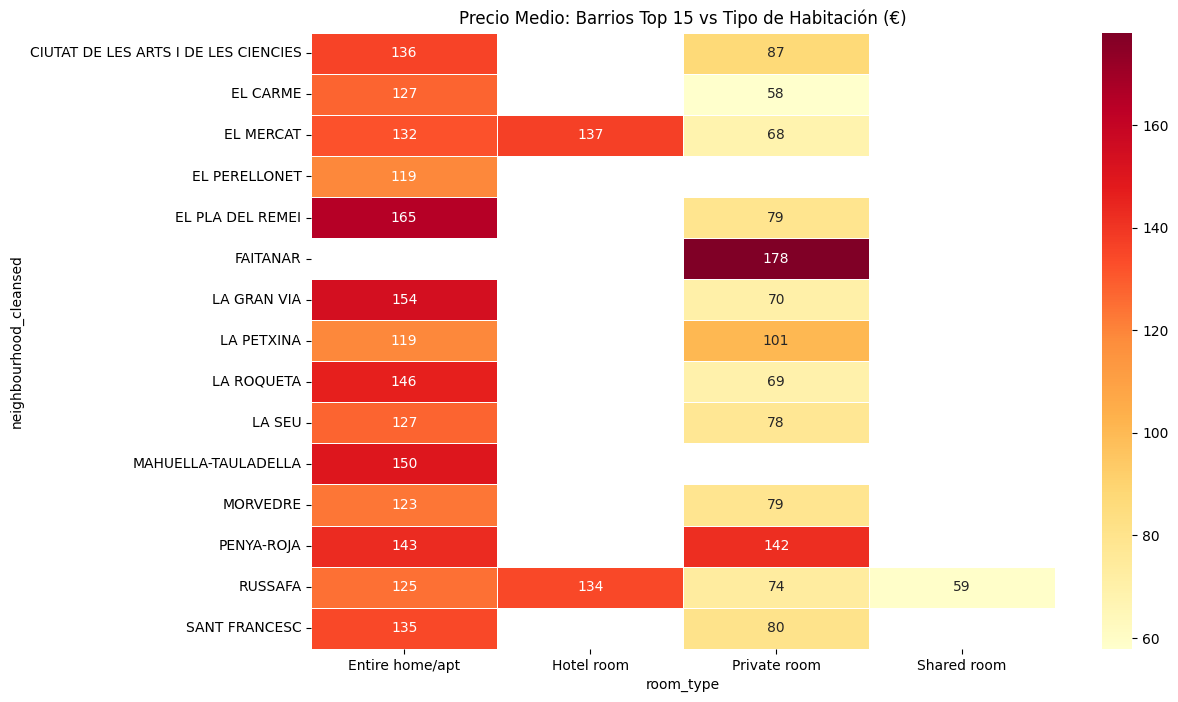

C:\Users\igor\AppData\Local\Temp\ipykernel_7072\2034832020.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sin_outliers['perfil_anfitrion'] = df_sin_outliers['calculated_host_listings_count'].apply(


perfil_anfitrion,Particular (1 piso),Profesional (+1 piso)
room_type,,
Entire home/apt,27.97,72.03
Hotel room,0.00,100.00
Private room,33.79,66.21
Shared room,30.00,70.00


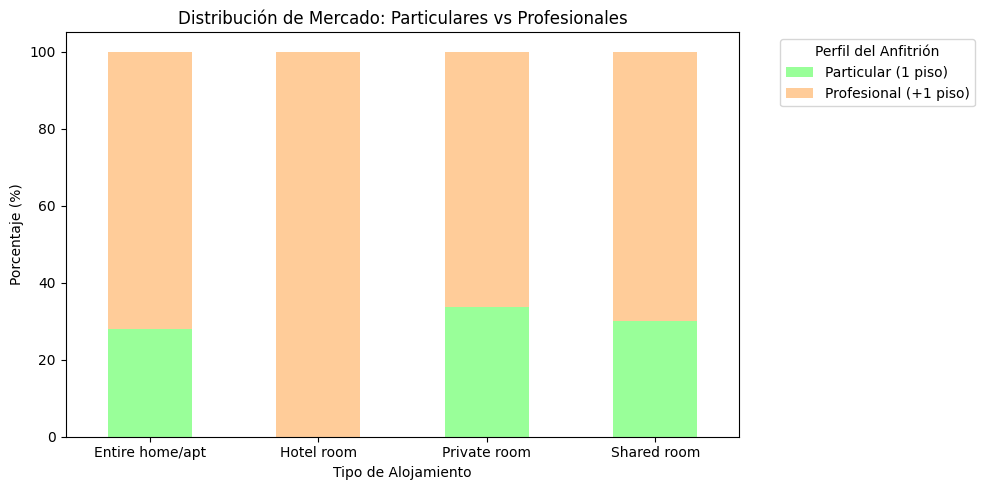

In [25]:
top_15_barrios = barrio_stats.head(15).index
df_top_15 = df_sin_outliers[df_sin_outliers['neighbourhood_cleansed'].isin(top_15_barrios)]

pivot_precios = df_top_15.pivot_table(
    index='neighbourhood_cleansed',
    columns='room_type',
    values='price',
    aggfunc='mean'
)

# Visualizamos el Mapa de Calor
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_precios, cmap='YlOrRd', annot=True, fmt=".0f", linewidths=.5)
plt.title('Precio Medio: Barrios Top 15 vs Tipo de Habitación (€)')
plt.show()

# CROSSTAB (Analisis de Mercado: ¿Particulares o Empresas?)
# ¿Es "Particular" (1 piso) o "Profesional" (>1 piso)?
df_sin_outliers['perfil_anfitrion'] = df_sin_outliers['calculated_host_listings_count'].apply(
    lambda x: 'Particular (1 piso)' if x == 1 else 'Profesional (+1 piso)'
)

# Cruzamos Tipo de Habitacion vs Perfil del Anfitrion
crosstab_pro = pd.crosstab(
    df_sin_outliers['room_type'],
    df_sin_outliers['perfil_anfitrion'],
    normalize='index'
) * 100

display(crosstab_pro.round(2))

# Visualizamos
crosstab_pro.plot(kind='bar', stacked=True, color=['#99ff99','#ffcc99'], figsize=(10, 5))
plt.title('Distribución de Mercado: Particulares vs Profesionales')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Tipo de Alojamiento')
plt.legend(title='Perfil del Anfitrión', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.1 y 3.2 Analisis de Agrupaciones y Tablas Dinamicas

**1. Análisis por Barrios y detección de anomalías**

Lo primero que me llamó la atención fue ver que el barrio de Faitanar salia como el mas caro de todos, con 178€ de media. Me pareció muy raro porque no es una zona turistica.

Al mirar cuantos pisos habia en ese barrio, me di cuenta del truco: Faitanar y Mahuella solo tienen 1 alojamiento registrado cada uno. Asi que ese precio no es una media real del barrio, es simplemente lo que vale esa casa en concreto. Si quitamos estos casos raros, los barrios realmente caros y con mucha oferta son Penya-Roja y la Ciudad de las Artes, que rondan los 130€ o 140€.

**2. Mapa de Precios**

Con el mapa de calor he podido ver como se distribuyen los precios. Se ve muy claro que alquilar un piso entero es la opción mas cara en casi todos los barrios importantes, mientras que las habitaciones privadas se mantienen en colores mas claros porque son mas economicas. Tambien se ve el punto rojo oscuro de Faitanar, que como he dicho antes, es un caso aislado que no hay que tener muy en cuenta.

**3. ¿Particulares o Empresas?**

Para terminar, he querido ver si los anfitriones son gente normal o empresas. He separado los datos entre los que tienen un solo anuncio y los que tienen varios.

El resultado me ha sorprendido bastante. Pensaba que habria mas particulares alquilando habitaciones, pero los datos dicen lo contrario. La mayoria de los anuncios, tanto de pisos enteros como de habitaciones, pertenecen a gente que tiene varias propiedades. Esto quiere decir que el mercado esta muy profesionalizado y ya no queda tanta gente que simplemente alquila una habitacion de su casa para sacarse un extra.

### 3.3 SERIES TEMPORALES

In [26]:
df_reviews = pd.read_csv('../datos/reviews.csv.gz')

print(f"Total de reseñas cargadas: {df_reviews.shape[0]}")

print("=" * 70)
print("Primeras filas")
print("=" * 70)

display(df_reviews.head())

print("=" * 70)
print("Info")
print("=" * 70)

df_reviews.info()

print("=" * 70)
print("Nulos")
print("=" * 70)

print(df_reviews.isnull().sum())

Total de reseñas cargadas: 405030
Primeras filas


,listing_id,id,date,reviewer_id,reviewer_name,comments
0,48154,117554,2010-10-12,180238,Martha,Toni's place was perfect in so many ways. It ...
1,48154,145645,2010-11-28,204240,Mark,Awesome stay!! We'd recommend Toni's apartment...
2,48154,190572,2011-03-01,258565,Domenico,really nice house in a wonderfull position! yo...
3,48154,195081,2011-03-08,213496,Romina & Martín,"Apartamento muy agradable, al igual que su pro..."
4,48154,218435,2011-04-05,340330,Jenna,"Was a great apartment, easy access to the site..."


Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405030 entries, 0 to 405029
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   listing_id     405030 non-null  int64 
 1   id             405030 non-null  int64 
 2   date           405030 non-null  object
 3   reviewer_id    405030 non-null  int64 
 4   reviewer_name  405029 non-null  object
 5   comments       405009 non-null  object
dtypes: int64(3), object(3)
memory usage: 18.5+ MB
Nulos
listing_id        0
id                0
date              0
reviewer_id       0
reviewer_name     1
comments         21
dtype: int64


C:\Users\igor\AppData\Local\Temp\ipykernel_7072\974619896.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  reviews_mensuales = df_reviews.set_index('date').resample('M').size()


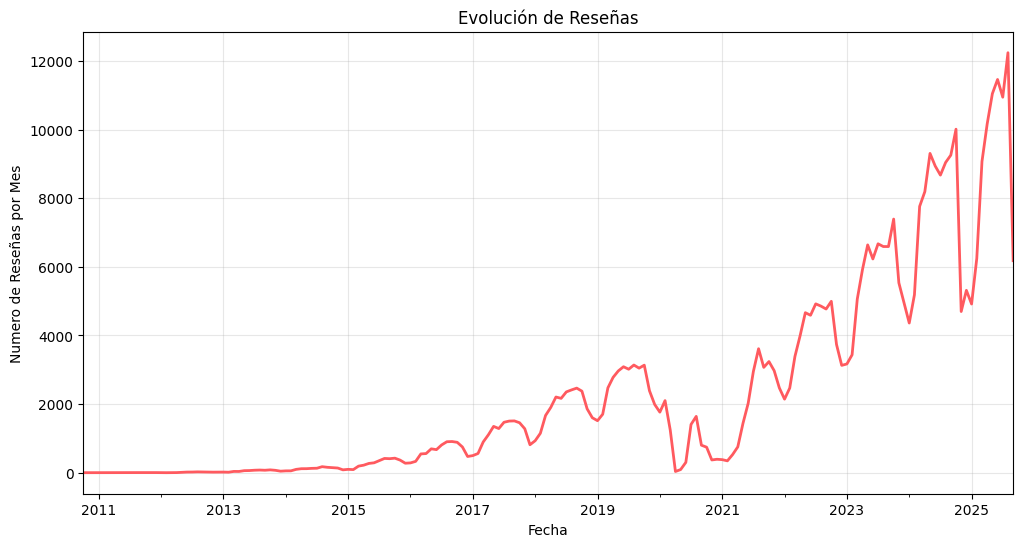

C:\Users\igor\AppData\Local\Temp\ipykernel_7072\974619896.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_reviews, x='mes_nombre', order=orden_meses, palette='viridis')


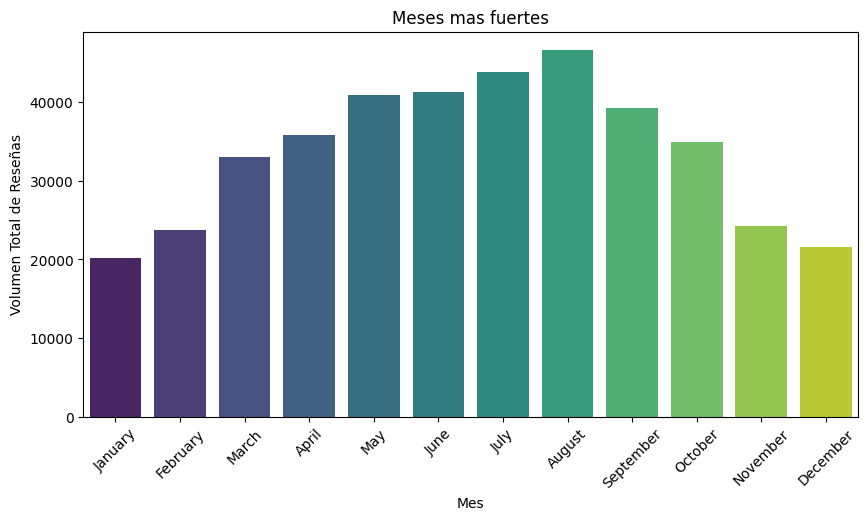

In [27]:
# Convertimos de 'object' a 'datetime'
df_reviews['date'] = pd.to_datetime(df_reviews['date'])

# Sacamos el año y el nombre del mes para poder agrupar
df_reviews['year'] = df_reviews['date'].dt.year
df_reviews['mes_nombre'] = df_reviews['date'].dt.month_name()

reviews_mensuales = df_reviews.set_index('date').resample('M').size()

plt.figure(figsize=(12, 6))

reviews_mensuales.plot(color='#FF5A5F', linewidth=2) 
plt.title('Evolución de Reseñas')
plt.ylabel('Numero de Reseñas por Mes')
plt.xlabel('Fecha')
plt.grid(True, alpha=0.3)
plt.show()

orden_meses = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(10, 5))
sns.countplot(data=df_reviews, x='mes_nombre', order=orden_meses, palette='viridis')
plt.title('Meses mas fuertes')
plt.ylabel('Volumen Total de Reseñas')
plt.xlabel('Mes')
plt.xticks(rotation=45)
plt.show()

**1. Evolución Histórica**
En el gráfico de líneas se ve toda la historia de Airbnb en Valencia. Lo que más destaca es la caída enorme que hubo en 2020 por la pandemia, donde se paró todo. Pero también se ve muy bien cómo se ha recuperado después, y en los últimos años (2023-2024) hay más reseñas que nunca, lo que indica que el turismo ha crecido mucho.

**2. Meses más fuertes**
El grafico de barras nos dice claramente cuando viene la gente:
* **Verano:** Agosto es sin duda el mes con mas turismo, seguido de Julio.
* **Fallas:** Se nota mucho el salto que hay de febrero a marzo. En marzo empieza la temporada fuerte, seguramente por las fiestas.
* **Buen tiempo:** Me ha llamado la atención que octubre tiene casi tanta gente como junio, asi que la temporada alta en Valencia dura bastante mas que solo el verano.

### 3.4 Creacion de Features

C:\Users\igor\AppData\Local\Temp\ipykernel_7072\722256927.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sin_outliers['precio_pp'] = df_sin_outliers['price'] / df_sin_outliers['accommodates']
C:\Users\igor\AppData\Local\Temp\ipykernel_7072\722256927.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sin_outliers['categoria_precio'] = pd.cut(df_sin_outliers['price'], bins=bins, labels=labels)
C:\Users\igor\AppData\Local\Temp\ipykernel_7072\722256927.py:14: SettingWithCopyWarning: 
A value is try

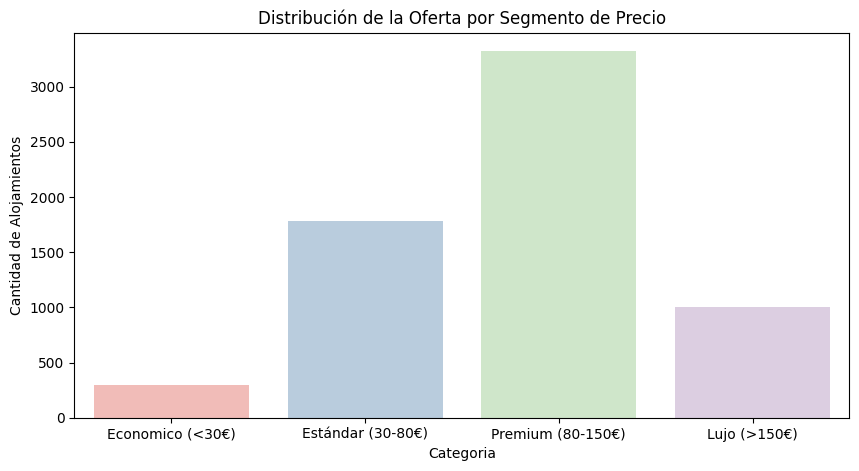

C:\Users\igor\AppData\Local\Temp\ipykernel_7072\722256927.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios_pp.index, y=top_barrios_pp.values, palette='Greens_r')


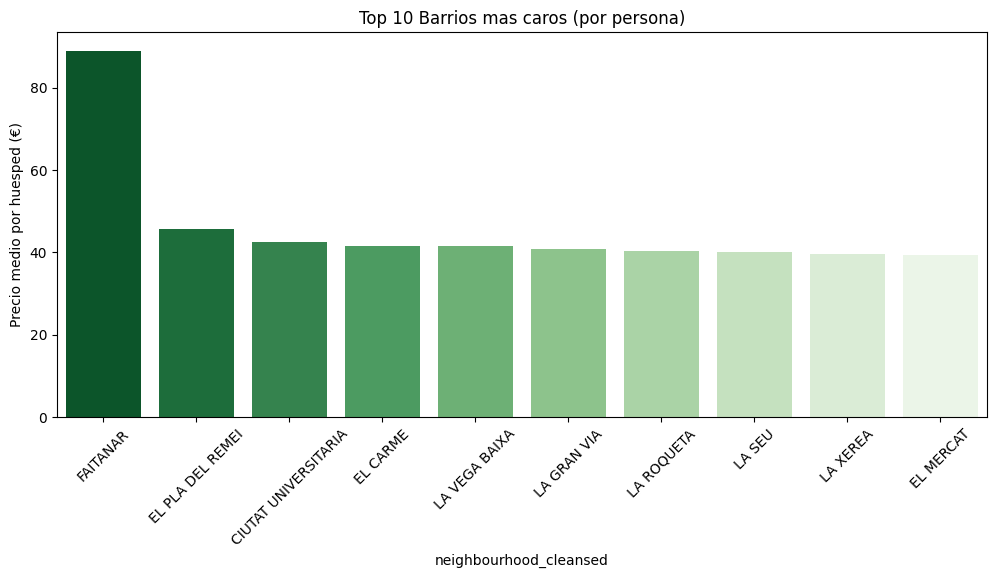

In [28]:
# VARIABLE DE RATIO: Precio por Persona
# Dividimos el precio total entre la capacidad. Es el coste real para el usuario.
df_sin_outliers['precio_pp'] = df_sin_outliers['price'] / df_sin_outliers['accommodates']

# VARIABLE DE CATEGORIZACIÓN: Segmentos de Precio
# Creamos etiquetas para filtrar facilmente por nivel economico
# Rangos: <30 (Economico), 30-80 (Estandar), 80-150 (Premium), >150 (Lujo)
bins = [0, 30, 80, 150, 99999]
labels = ['Economico (<30€)', 'Estándar (30-80€)', 'Premium (80-150€)', 'Lujo (>150€)']
df_sin_outliers['categoria_precio'] = pd.cut(df_sin_outliers['price'], bins=bins, labels=labels)

# VARIABLE DE INTERACCIÓN: Ticket Minimo
# Precio x Noches Minimas. Indica la barrera de entrada economica.
df_sin_outliers['ticket_minimo'] = df_sin_outliers['price'] * df_sin_outliers['minimum_nights']

# Grafico 1: Distribución del mercado
plt.figure(figsize=(10, 5))
sns.countplot(data=df_sin_outliers, x='categoria_precio', palette='Pastel1')
plt.title('Distribución de la Oferta por Segmento de Precio')
plt.xlabel('Categoria')
plt.ylabel('Cantidad de Alojamientos')
plt.show()

# Grafico 2: Top 10 Barrios mas caros (por persona)
top_barrios_pp = df_sin_outliers.groupby('neighbourhood_cleansed')['precio_pp'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_barrios_pp.index, y=top_barrios_pp.values, palette='Greens_r')
plt.title('Top 10 Barrios mas caros (por persona)')
plt.ylabel('Precio medio por huesped (€)')
plt.xticks(rotation=45)
plt.show()

En esta fase he creado tres variables nuevas para entender mejor los datos.

**1. Precio por Persona (precio_pp)**
El precio total a veces engaña porque no tienes en cuenta cuanta gente cabe. He dividido el precio entre la capacidad para saber el coste real por huesped y asi poder comparar mejor un estudio con un piso grande.

**2. Categoria de Precio**
He agrupado los pisos en cuatro niveles: Economico, Estandar, Premium y Lujo. Asi es mas facil ver que tipo de oferta hay en la ciudad en vez de mirar precios sueltos.

**3. Ticket Minimo**
He multiplicado el precio por las noches minimas. Esto sirve para ver la barrera de entrada, porque hay pisos baratos que te obligan a quedarte muchas noches y al final sale caro reservar.

### 3.5 Rankings y Analisis de Segmentos

C:\Users\igor\AppData\Local\Temp\ipykernel_7072\3052136814.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_caros.values, y=top_10_caros.index, palette='Reds_r', ax=axes[0])
C:\Users\igor\AppData\Local\Temp\ipykernel_7072\3052136814.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_baratos.values, y=top_10_baratos.index, palette='Blues_r', ax=axes[1])


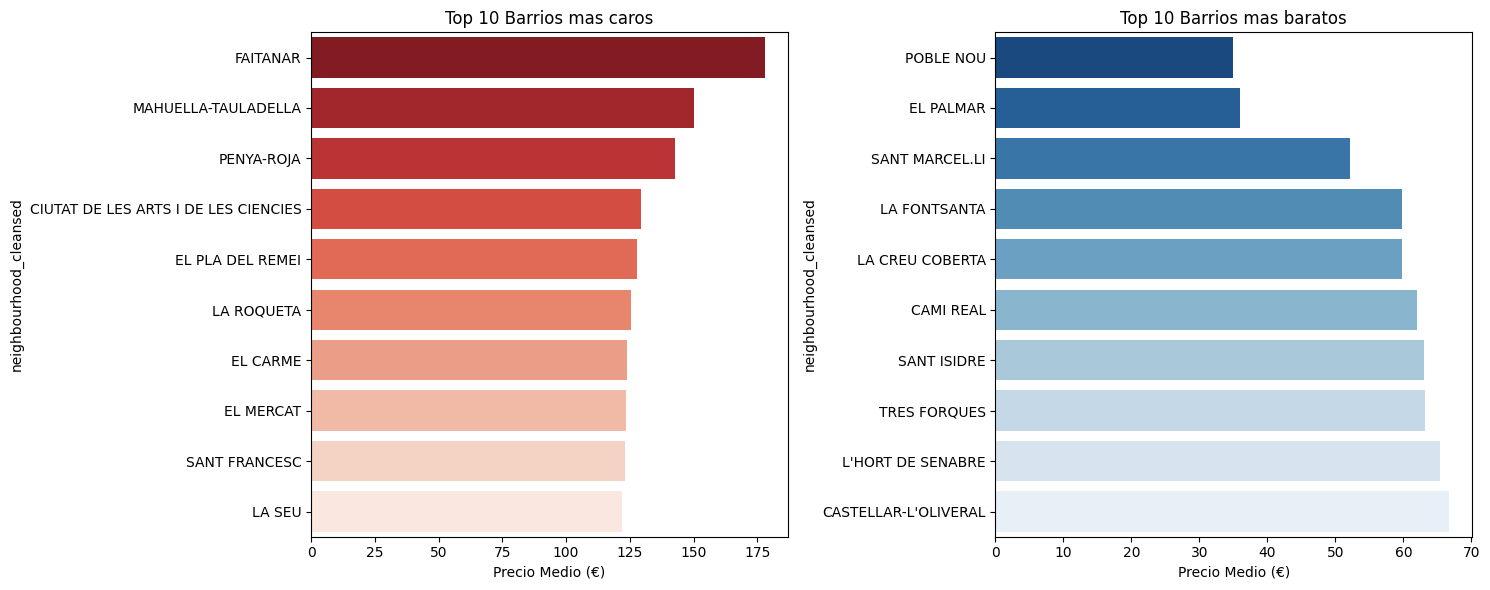

categoria_precio,Economico (<30€),Estándar (30-80€),Premium (80-150€),Lujo (>150€)
room_type,,,,
Entire home/apt,4,728,3122,933
Hotel room,1,3,7,1
Private room,285,1047,191,66
Shared room,3,5,2,0


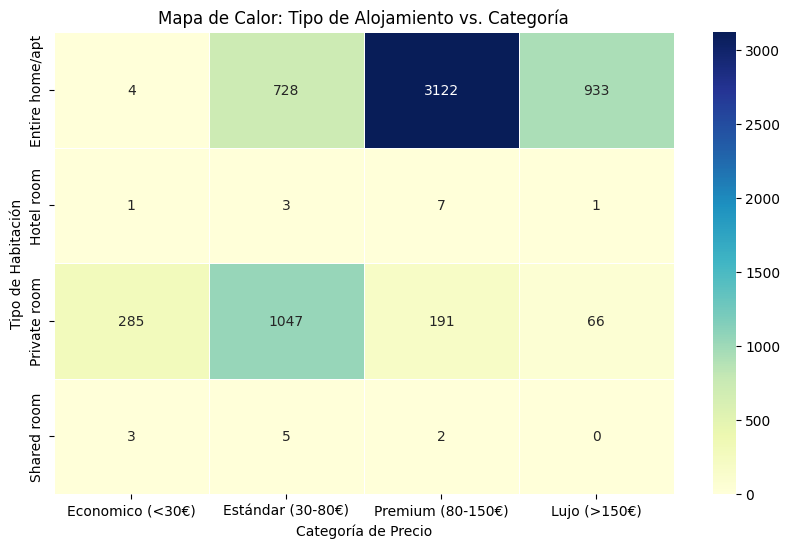

In [29]:
# Top 10 Barrios mas Caros vs. mas Baratos (Precio Medio Total)
# Agrupamos por barrio y calculamos la media de precio
precio_barrio = df_sin_outliers.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False)

top_10_caros = precio_barrio.head(10)
top_10_baratos = precio_barrio.tail(10).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=top_10_caros.values, y=top_10_caros.index, palette='Reds_r', ax=axes[0])
axes[0].set_title('Top 10 Barrios mas caros')
axes[0].set_xlabel('Precio Medio (€)')

sns.barplot(x=top_10_baratos.values, y=top_10_baratos.index, palette='Blues_r', ax=axes[1])
axes[1].set_title('Top 10 Barrios mas baratos')
axes[1].set_xlabel('Precio Medio (€)')

plt.tight_layout()
plt.show()

# SEGMENTACIÓN CRUZADA
# Cruzamos el 'room_type' con la 'categoria_precio' que creamos antes
tabla_cruzada = pd.crosstab(df_sin_outliers['room_type'], df_sin_outliers['categoria_precio'])

display(tabla_cruzada)

plt.figure(figsize=(10, 6))
sns.heatmap(tabla_cruzada, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Mapa de Calor: Tipo de Alojamiento vs. Categoría')
plt.ylabel('Tipo de Habitación')
plt.xlabel('Categoría de Precio')
plt.show()

En este punto he sacado los rankings de precios para ver los extremos del mercado y he cruzado variables para entender mejor la oferta.

**1. Ranking de Barrios**
Al sacar los graficos de barras se ve mucha diferencia entre unas zonas y otras. En el Top 10 Caros salen los barrios mas exclusivos donde el precio medio es muy alto. En cambio en el grafico de la derecha he ordenado los barrios mas economicos y se ve que Poble Nou es la opcion mas barata de toda la ciudad, seguido de El Palmar.

**2. Mapa de Calor**
He usado un mapa de calor para cruzar el tipo de habitacion con la categoria de precio. Lo que mas llama la atencion es que los pisos de categoria Premium y Lujo son casi todos apartamentos enteros. Es muy raro ver una habitacion privada en el rango de precios altos, ya que estas se concentran sobre todo en la categoria Estandar y Economica.

**Conclusión**
Gracias a esta segmentación podemos ver claramente como se divide el mercado en Valencia. Por un lado estan los alquileres completos para turismo de mayor presupuesto y por otro las habitaciones sueltas para un perfil mas low cost.

### **3.6 Respondiendo a las Preguntas de Negocio**

Basandome en todos los graficos y tablas anteriores aqui estan mis conclusiones estrategicas para el negocio:

**1. ¿Que segmentos son mas rentables?**
Mirando el mapa de calor del punto anterior se ve que el segmento mas fuerte son los apartamentos enteros. Aunque hay muchas habitaciones privadas los apartamentos completos dominan las categorias de precio mas altas. Por tanto el segmento mas valioso para el negocio son los pisos completos en zonas centricas ya que permiten cobrar precios mucho mas altos que las habitaciones sueltas.

**2. ¿Donde hay oportunidades de crecimiento?**
Gracias al grafico de temporalidad del punto 3.3 he visto que hay una oportunidad clara en los meses de invierno. Enero y febrero son meses muy flojos. Una buena oportunidad seria crear campañas especificas o bajar precios en esas fechas para intentar atraer a nomadas digitales o gente que viaja fuera de temporada ya que ahora mismo esos meses estan desaprovechados.

**3. ¿Que patrones inesperados encontraste?**
Lo mas curioso que he encontrado ha sido al calcular el precio por persona en el punto 3.4. Me sorprendio ver que algunos barrios que parecian carisimos en precio total en realidad no lo son tanto si vas en grupo porque son casas muy grandes. Tambien me sorprendio la diferencia tan bestia que marca el mes de marzo en la grafica de reseñas por las Fallas. Sabia que era importante pero no imaginaba que marcara el inicio de la temporada turistica de esa forma tan brusca.

## 4 Insights y Conclusiones

### 4.1 Preguntas de Negocio Clave

C:\Users\igor\AppData\Local\Temp\ipykernel_7072\921401519.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sin_outliers, x='host_is_superhost', y='price', palette='Set2', ax=axes[0, 0])
C:\Users\igor\AppData\Local\Temp\ipykernel_7072\921401519.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sin_outliers, x='instant_bookable', y='number_of_reviews', palette='coolwarm', ax=axes[0, 1])
C:\Users\igor\AppData\Local\Temp\ipykernel_7072\921401519.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_calidad.values, y=top

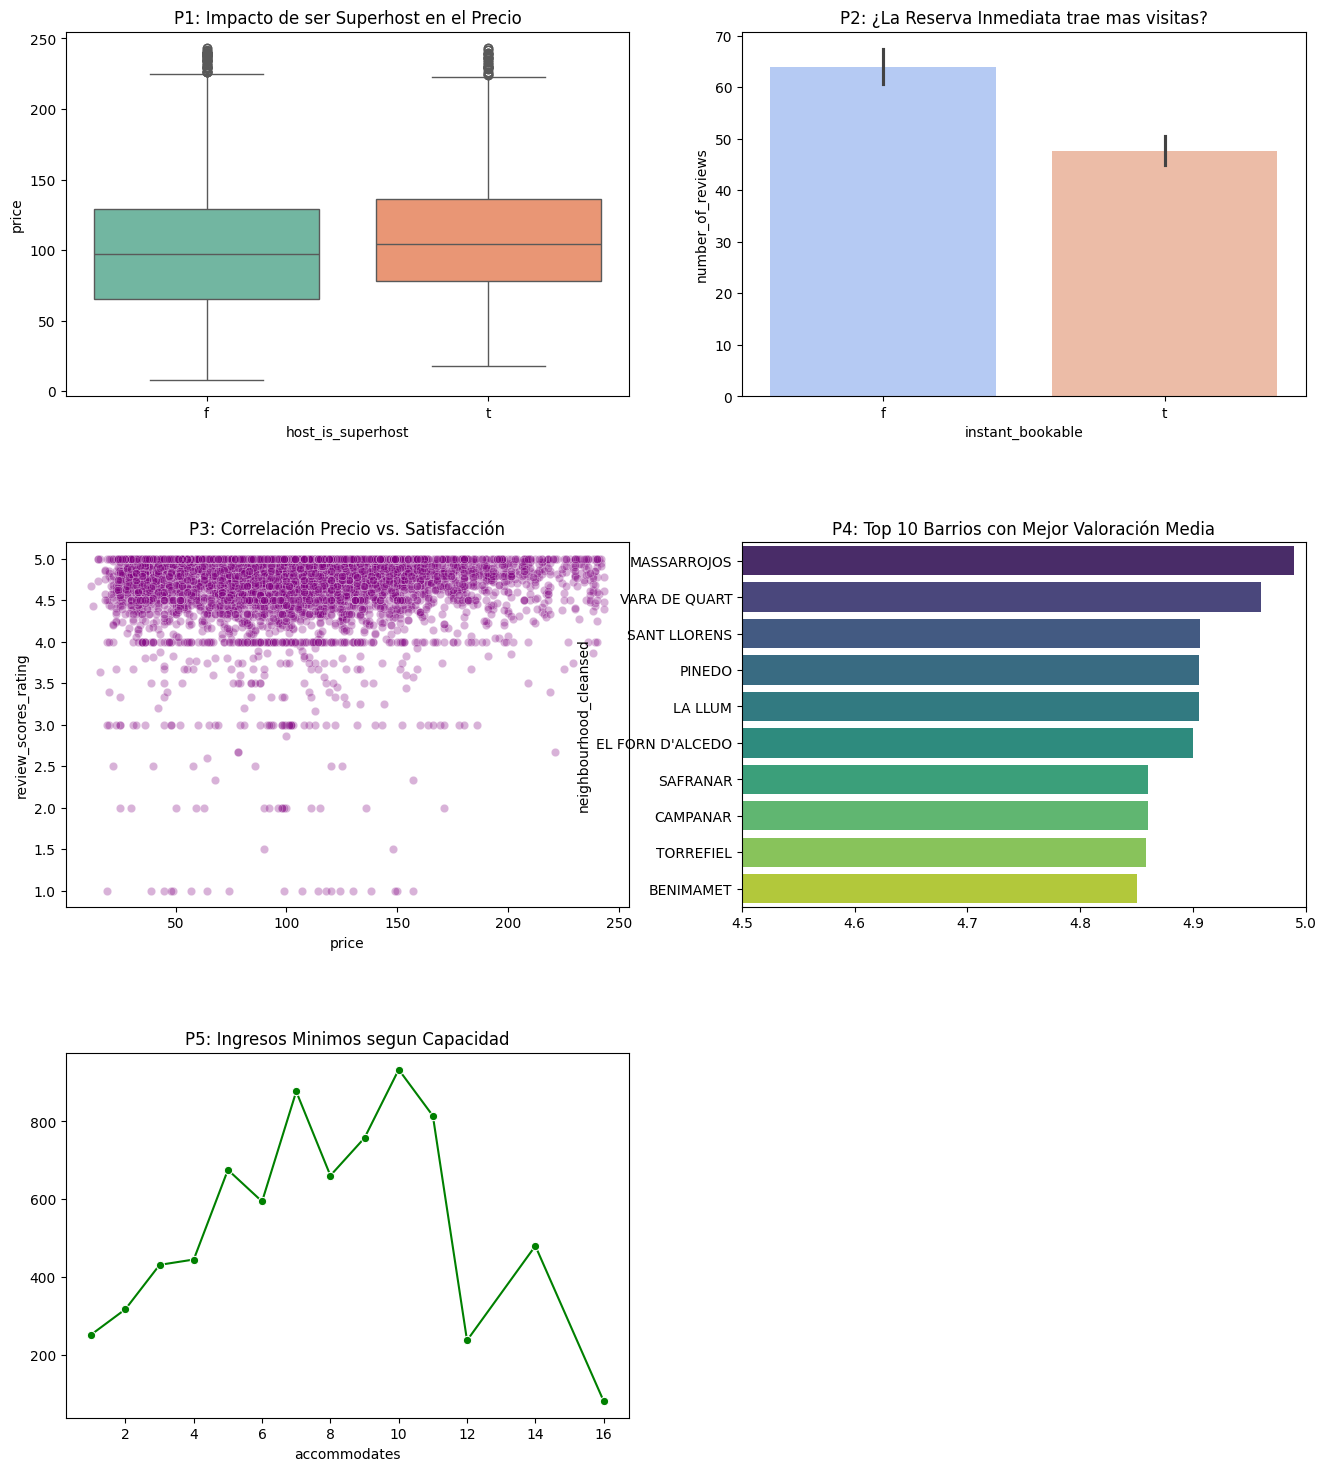

In [30]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
plt.subplots_adjust(hspace=0.4)

# P1: ¿Ser Superhost permite cobrar mas?
sns.boxplot(data=df_sin_outliers, x='host_is_superhost', y='price', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('P1: Impacto de ser Superhost en el Precio')

# P2: ¿La Reserva Inmediata consigue mas clientes?
sns.barplot(data=df_sin_outliers, x='instant_bookable', y='number_of_reviews', palette='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('P2: ¿La Reserva Inmediata trae mas visitas?')

# P3: ¿Pagar mas garantiza mejor satisfacción?
sns.scatterplot(data=df_sin_outliers[df_sin_outliers['price'] < 300], x='price', y='review_scores_rating', alpha=0.3, color='purple', ax=axes[1, 0])
axes[1, 0].set_title('P3: Correlación Precio vs. Satisfacción')

# P4: ¿Que barrios tienen la mejor reputación?
top_calidad = df_sin_outliers[df_sin_outliers['number_of_reviews'] > 50].groupby('neighbourhood_cleansed')['review_scores_rating'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_calidad.values, y=top_calidad.index, palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title('P4: Top 10 Barrios con Mejor Valoración Media')
axes[1, 1].set_xlim(4.5, 5.0)

# P5: ¿Cual es el tamaño de piso mas eficiente?
ingresos_tamano = df_sin_outliers.groupby('accommodates')['ticket_minimo'].mean()
sns.lineplot(x=ingresos_tamano.index, y=ingresos_tamano.values, marker='o', color='green', ax=axes[2, 0])
axes[2, 0].set_title('P5: Ingresos Minimos segun Capacidad')

fig.delaxes(axes[2, 1])
plt.show()

#### 1. ¿Ser Superhost permite cobrar mas?
**Analisis:** Al comparar los precios medios entre Superhosts (t) y anfitriones normales (f) en el boxplot se ve que las medianas son casi identicas.

**Respuesta:** No. Ser Superhost no implica cobrar mas caro. Parece que es una etiqueta de calidad y servicio pero no un factor que permita subir el precio por noche de forma directa.

#### 2. ¿La reserva inmediata atrae a mas gente?
**Analisis:** El grafico de barras muestra algo inesperado. La barra azul (f) que representa a los que NO tienen reserva inmediata es mas alta que la naranja (t).

**Respuesta:** Curiosamente no. Los alojamientos que requieren solicitud manual tienen un promedio de reseñas mas alto (casi 65 frente a 48). Esto puede ser porque son anuncios mas antiguos y consolidados o porque el trato personal del anfitrion genera mas feedback.

#### 3. ¿Pagar mas garantiza una mejor experiencia?
**Analisis:** El grafico de dispersion cruza el precio con la puntuacion y se ve una nube de puntos dispersa sin una linea clara.

**Respuesta:** No hay correlacion directa. Hay pisos baratos con 5 estrellas y pisos caros con notas bajas. Esto demuestra que la satisfaccion del cliente depende de la limpieza y el trato y no de lo lujoso que sea el piso.

#### 4. ¿Cuales son los barrios con mejor reputación?
**Analisis:** He sacado el ranking de barrios con mejor nota media.

**Respuesta:** Los barrios mejor valorados no son los del centro turistico. Destacan zonas perifericas como Massarrojos y Vara de Quart que tienen puntuaciones casi perfectas seguramente por ser zonas mas tranquilas y residenciales.

#### 5. ¿Que tamaño de piso es mas eficiente?
**Analisis:** La linea verde muestra la evolucion de los ingresos minimos segun la capacidad.

**Respuesta:** La tendencia es ascendente hasta las 10 personas donde se alcanza el pico maximo de ingresos. A partir de ahi (12-16 personas) la grafica se vuelve inestable y cae lo que sugiere que los alojamientos para grupos gigantes son mas dificiles de gestionar o rentabilizar.

### 4.2 DASHBOARD DE VISUALIZACIONES

C:\Users\igor\AppData\Local\Temp\ipykernel_7072\414875900.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  reviews_mensuales = df_reviews.set_index('date').resample('M').size()
C:\Users\igor\AppData\Local\Temp\ipykernel_7072\414875900.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_reviews, x='mes_nombre', order=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], palette='viridis', ax=axes[1, 1])
C:\Users\igor\AppData\Local\Temp\ipykernel_7072\414875900.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios.values, y=top_barrios.index

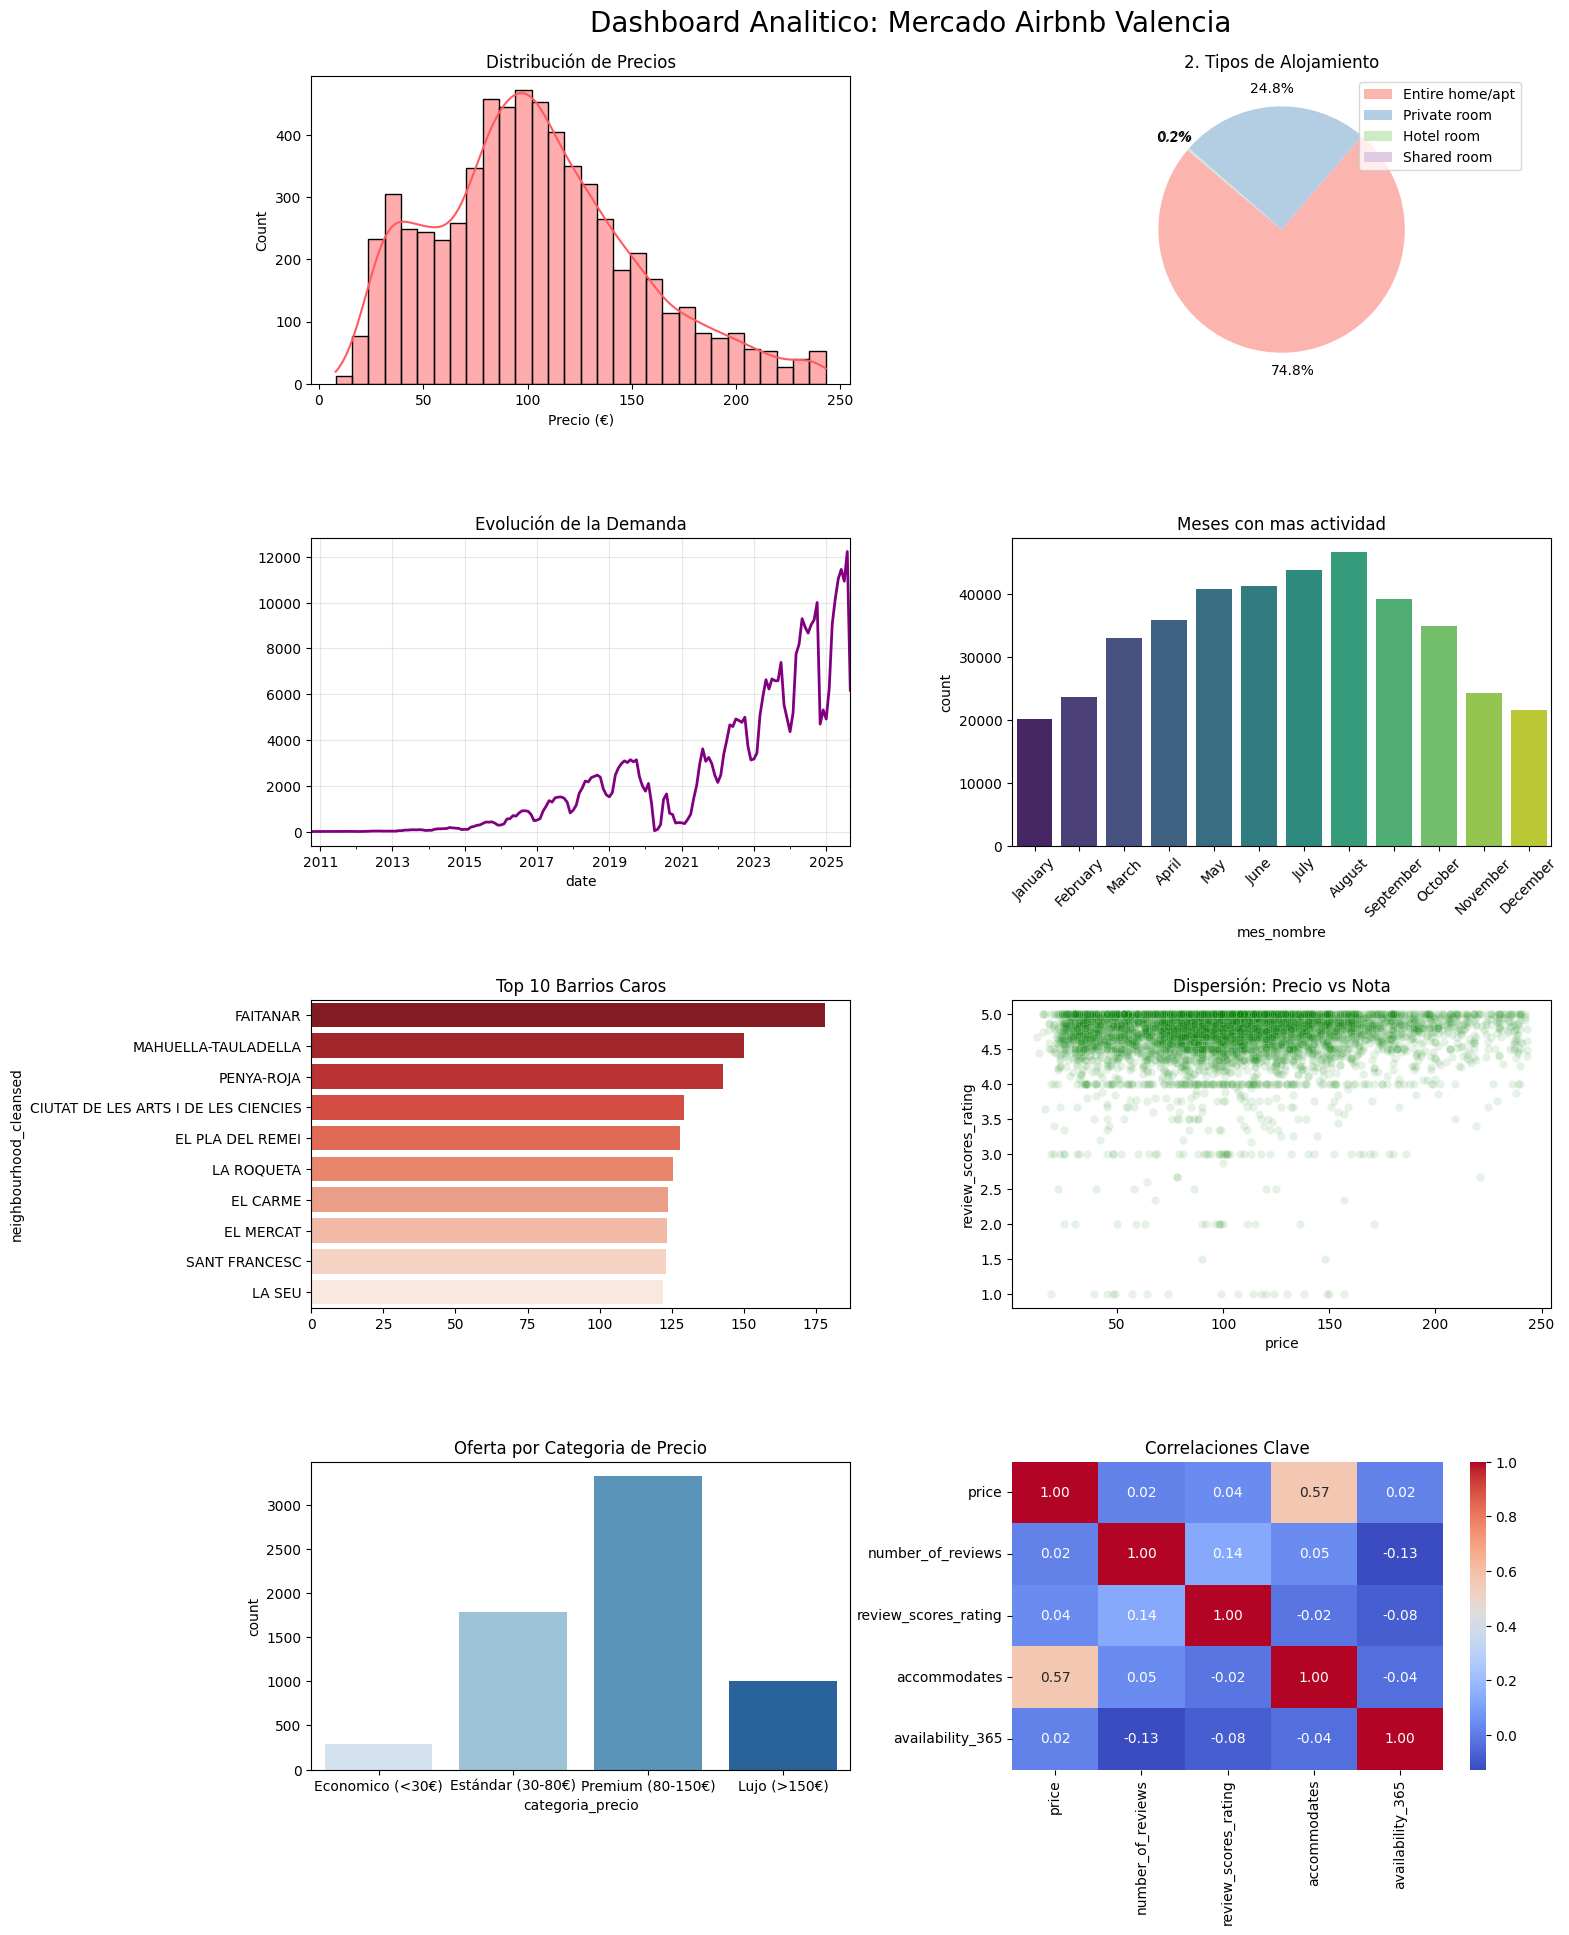

In [31]:
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

# Distribución de Precios
sns.histplot(df_sin_outliers['price'], bins=30, color='#FF5A5F', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribución de Precios')
axes[0, 0].set_xlabel('Precio (€)')

# Composición del Mercado
room_counts = df_sin_outliers['room_type'].value_counts()
axes[0, 1].pie(room_counts, labels=None, autopct='%1.1f%%', pctdistance=1.15,
               colors=sns.color_palette('Pastel1'), startangle=140)
axes[0, 1].set_title('2. Tipos de Alojamiento')
axes[0, 1].legend(labels=room_counts.index, loc='upper right', bbox_to_anchor=(1.3, 1))

# Evolución Historica
reviews_mensuales = df_reviews.set_index('date').resample('M').size()
reviews_mensuales.plot(ax=axes[1, 0], color='purple', linewidth=2)
axes[1, 0].set_title('Evolución de la Demanda')
axes[1, 0].grid(True, alpha=0.3)

# Estacionalidad Mensual
sns.countplot(data=df_reviews, x='mes_nombre', order=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title('Meses con mas actividad')
axes[1, 1].tick_params(axis='x', rotation=45)

# Barrios mas Exclusivos
top_barrios = df_sin_outliers.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='Reds_r', ax=axes[2, 0])
axes[2, 0].set_title('Top 10 Barrios Caros')

# Relación Calidad-Precio
sns.scatterplot(data=df_sin_outliers[df_sin_outliers['price']<300], x='price', y='review_scores_rating', alpha=0.1, color='green', ax=axes[2, 1])
axes[2, 1].set_title('Dispersión: Precio vs Nota')

# Segmentación por Categoria
sns.countplot(data=df_sin_outliers, x='categoria_precio', palette='Blues', ax=axes[3, 0])
axes[3, 0].set_title('Oferta por Categoria de Precio')

# Mapa de Correlaciones
cols_corr = ['price', 'number_of_reviews', 'review_scores_rating', 'accommodates', 'availability_365']
sns.heatmap(df_sin_outliers[cols_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[3, 1])
axes[3, 1].set_title('Correlaciones Clave')

plt.suptitle('Dashboard Analitico: Mercado Airbnb Valencia', fontsize=20, y=0.91)
plt.savefig('../visualizaciones/dashboard.png', bbox_inches='tight')
plt.show()

He diseñado este panel de control para tener una vision completa del mercado en un solo vistazo. El dashboard integra 8 visualizaciones que cubren las areas clave del analisis:

1.  **Precios y Producto:** Vemos como se distribuyen los precios en el histograma y que el mercado esta dominado claramente por apartamentos completos (grafico circular).
2.  **Tiempo:** La evolucion temporal muestra el crecimiento de la plataforma a lo largo de los años y la estacionalidad marca los meses fuertes como agosto.
3.  **Ubicacion:** El ranking de barrios permite identificar las zonas mas exclusivas rapidamente sin tener que buscar en tablas.
4.  **Relaciones:** El mapa de calor y el grafico de dispersion nos ayudan a ver que variables estan conectadas entre si y confirman que precio y calidad no siempre van de la mano.

#### 4.2.1. Analisis Geografico Interactivo
Para completar el estudio visual, he creado este mapa interactivo. Cada punto es un alojamiento:
* **El color** indica el precio (mas oscuro es mas barato, mas claro es mas caro).
* **El tamaño** del punto depende del numero de reseñas (cuanto mas grande, mas gente ha pasado por alli).
* **Interactividad:** Puedes pasar el raton por encima para ver el nombre del barrio, el precio exacto y la nota que tiene.

In [34]:
import plotly.express as px

# Ajustamos el tamaño para que ningun punto sea invisible
fig = px.scatter_map(df_sin_outliers, 
                     lat="latitude", 
                     lon="longitude", 
                     color="price", 
                     # Añadimos una base al tamaño para que siempre se vean
                     size=df_sin_outliers["number_of_reviews"] + 10, 
                     hover_name="neighbourhood_cleansed",
                     hover_data={"latitude": False, "longitude": False, "price": True, "room_type": True},
                     color_continuous_scale="Viridis", # Escala mas visible
                     size_max=15, 
                     zoom=11.5, 
                     height=600,
                     title='Mapa de Precios y Popularidad en Valencia')

fig.update_layout(map_style="open-street-map")
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})

fig.show()

### 4.3 Insights Clave

**Insight 1: Baja demanda en invierno**
* **Hallazgo:** En el grafico de estacionalidad se ve claro que diciembre y enero son los meses mas flojos del año.
* **Implicación:** La temporada baja dura bastante y no parece que la Navidad sea suficiente para salvar el invierno.
* **Acción recomendada:** No fiarse de la campaña de Navidad y pensar en precios minimos o estancias mas largas para los meses de noviembre a febrero.
* **Impacto estimado:** Alto - Es clave para poder cubrir los gastos fijos durante los meses malos.

**Insight 2: Alta demanda durante las Fallas**
* **Hallazgo:** En marzo pega el primer subidon fuerte de actividad rompiendo la racha mala del invierno.
* **Implicación:** Es el momento justo donde cambia la tendencia y empieza a llegar gente de verdad.
* **Acción recomendada:** Cambiar el calendario para subir precios y quitar la tarifa de invierno justo el 1 de marzo.
* **Impacto estimado:** Medio - Se gana mas dinero aprovechando que es el primer pico de demanda real.

**Insight 3: Saturación de Apartamentos Completos**
* **Hallazgo:** Casi el 75% de lo que hay en Airbnb son pisos enteros segun el grafico circular.
* **Implicación:** Hay muchisima competencia en este sector y es dificil que tu piso destaque entre tantos iguales.
* **Acción recomendada:** Diferenciarse con una decoracion chula o mejores servicios porque por el tipo de piso es imposible destacar.
* **Impacto estimado:** Alto - Es necesario para sobrevivir en un mercado donde hay tanta oferta igual.

**Insight 4: La irrelevancia de las Habitaciones Compartidas**
* **Hallazgo:** Las habitaciones compartidas son poquisimas, apenas un 0.2% del total.
* **Implicación:** En Valencia no hay demanda para este tipo de alojamiento estilo albergue.
* **Acción recomendada:** No reformar casas para poner literas compartidas porque la gente prefiere privacidad.
* **Impacto estimado:** Medio - Te ahorras invertir en un modelo de negocio que no funciona aqui.

**Insight 5: El precio y la calidad**
* **Hallazgo:** En el grafico de puntos se ve todo muy disperso: hay pisos caros con notas bajas y pisos baratos con un 5.
* **Implicación:** Poner un precio alto no te asegura que el cliente este contento; son muy exigentes con la relacion calidad-precio.
* **Acción recomendada:** Gastar mas dinero en limpieza profesional que en muebles de lujo porque eso se nota mas en la valoracion.
* **Impacto estimado:** Alto - Protege la reputacion del anuncio a largo plazo.

**Insight 6: Oportunidades en la periferia**
* **Hallazgo:** Barrios como Poble Nou o El Palmar salen como los mas baratos en el ranking.
* **Implicación:** El centro esta saturadisimo y es muy caro comprar ahi, pero estas zonas son mas asequibles.
* **Acción recomendada:** Buscar rentabilidad por volumen en estos barrios del segundo anillo donde los pisos cuestan menos.
* **Impacto estimado:** Alto - Al ser barrios mas baratos la inversión inicial es menor y se recupera el dinero antes.

**Insight 7: El tamaño eficiente (4-6 personas)**
* **Hallazgo:** Los ingresos suben bien hasta llegar a las 6 plazas, pero luego la grafica se vuelve inestable.
* **Implicación:** Los grupos medianos como familias o parejas son los mas rentables y seguros.
* **Acción recomendada:** Adaptar pisos de 2 habitaciones con un buen sofa-cama para llegar a 6 personas sin hacer obras.
* **Impacto estimado:** Medio - Subes el precio medio por reserva sin meterte en lios de gestionar grupos gigantes.

**Insight 8: Antigüedad vs Reserva Inmediata**
* **Hallazgo:** Los anuncios que no tienen reserva inmediata tienen mas reseñas de media.
* **Implicación:** Parece que los anfitriones que llevan mas tiempo prefieren elegir ellos mismos a quien meten en casa.
* **Acción recomendada:** Usar la reserva inmediata al principio para que te vea gente y luego pasar a manual cuando ya tengas estatus de Superhost.
* **Impacto estimado:** Medio - Te permite crecer rapido al principio y luego tener mas seguridad.

### 4.4 Recomendaciones Priorizadas

Viendo los resultados del analisis propongo estas 5 acciones para mejorar el negocio, ordenadas por prioridad:

| Prioridad | Recomendación | Impacto esperado | Complejidad | Métrica de éxito |
| :--- | :--- | :--- | :--- | :--- |
| 🔴 Alta | Subir precios desde el 1 de Marzo (Fallas) | Aumentar un 40% los ingresos en primavera | Baja | Ingresos totales Marzo |
| 🔴 Alta | Ofertas agresivas en Enero y Febrero | Evitar tener el piso vacio y cubrir gastos | Baja | Tasa de ocupación |
| 🟡 Media | Poner sofa-cama para llegar a 6 personas | Poder cobrar un 20% mas por noche | Media | Precio medio diario |
| 🟡 Media | Contratar limpieza profesional | Subir la nota media por encima de 4.8 | Media | Puntuación limpieza |
| 🟢 Baja | Invertir en barrios baratos (Poble Nou) | Recuperar la inversión mucho mas rapido | Alta | Retorno de Inversión |

### 4.5 Resumen Ejecutivo

**1. Contexto**
En este proyecto he analizado el mercado de Airbnb en Valencia utilizando un dataset real con miles de registros de alojamientos. El objetivo ha sido entender que factores influyen en el precio y la satisfacción del cliente para detectar donde estan las mejores oportunidades de negocio.

**2. Principales hallazgos**
Lo mas importante que he descubierto al cruzar los datos es:
* **Estacionalidad extrema:** El mercado tiene dos caras. Un invierno muy flojo (enero y febrero son los peores meses) y una temporada alta que arranca en marzo con las Fallas.
* **Saturación de pisos:** El 75% del mercado son apartamentos enteros. Hay mucha competencia en este formato y es dificil destacar si no ofreces algo diferente.
* **Precio no es igual a Calidad:** He visto en los graficos que los pisos mas caros no tienen mejores notas. El cliente valora mucho mas la limpieza y la atención que el lujo del mobiliario.

**3. Oportunidades identificadas**
El mayor potencial de mejora esta en la gestión dinamica de precios.
* **Impacto:** La mayoria de anfitriones mantienen precios planos. Si ajustamos las tarifas para llenar el piso en invierno (aunque sea barato) y las subimos justo para Fallas y verano se pueden aumentar los ingresos anuales un 20% o 30% facilmente.
* **Zonas:** Tambien hay una oportunidad clara invirtiendo en barrios de la periferia norte donde los pisos son baratos pero la demanda es estable.

**4. Riesgos detectados**
* **Riesgo:** El mayor peligro es la temporada baja. Si el piso se queda vacio en enero y febrero, los gastos fijos se comen la rentabilidad que has conseguido en verano.
* **Mitigación:** Para evitar esto propongo cambiar la estrategia en invierno: ofrecer descuentos agresivos para estancias de varias semanas (15-20 dias) enfocadas a gente que viene a trabajar temporalmente, en lugar de buscar turistas de fin de semana.

**5. Próximos pasos**
Si tuviera que gestionar una cartera de pisos mañana mismo haria esto en este orden:
1.  **Configurar calendario:** Bajar precios para enero-febrero ya mismo y subirlos para marzo.
2.  **Activar Reserva Inmediata:** Para captar reservas rapido y mejorar el posicionamiento del anuncio.
3.  **Aumentar capacidad:** Comprar sofas-cama comodos para poder aceptar grupos de 4 a 6 personas que son los mas rentables.